In [1]:
import os
import sys

sys.path.append(os.path.abspath('..'))
from game import RepeatedReferenceGame, Trial
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter, defaultdict
import re

plt.rcParams['figure.dpi'] = 300

In [32]:
from nltk.tokenize import word_tokenize as tokenize
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
from nltk.stem.porter import *
stemmer = PorterStemmer()

In [3]:
import spacy
nlp = spacy.load("en_core_web_sm")

In [4]:
def editDistance(h, r, sent_len=None):
    #Reference: https://github.com/zszyellow/WER-in-python/blob/master/wer.py
    '''
    This function is to calculate the edit distance of reference sentence and the hypothesis sentence.

    Main algorithm used is dynamic programming.

    Attributes: 
        r -> the list of words produced by splitting reference sentence.
        h -> the list of words produced by splitting hypothesis sentence.
    '''
    d = np.zeros((len(r)+1)*(len(h)+1), dtype=np.uint8).reshape((len(r)+1, len(h)+1))
    for i in range(len(r)+1):
        d[i][0] = i
    for j in range(len(h)+1):
        d[0][j] = j
    for i in range(1, len(r)+1):
        for j in range(1, len(h)+1):
            if r[i-1] == h[j-1]:
                d[i][j] = d[i-1][j-1]
            else:
                substitute = d[i-1][j-1]+1
                insert = d[i][j-1]+1 
                delete = d[i-1][j]
                d[i][j] = min(substitute, insert, delete)
    # d=d[len(r)][len(h)]/len(r)
    d=d[len(r)][len(h)]
    
    if len(r)!=0:
        wnr=d/len(r)
        
    else:
        wnr=1 

    return d, wnr

def get_msg_distance(sentences):
 
    lemmatized_sentences = []
    sentences_lemma=[]
    for sentence in sentences:
        sentence = sentence.strip().strip('.').lower()
        doc = nlp(sentence)
        
     
        filtered_sentence_lemma = []
        for token in doc:
            if token.pos_ in ["NOUN", "ADJ", "VERB", "ADV", 'PROPN','NUM','PRON','ADP']:
                token_lemma=token.lemma_
                filtered_sentence_lemma.append(token_lemma)
          
        lemmatized_sentences.append(' '.join(filtered_sentence_lemma))
        sentences_lemma.append(filtered_sentence_lemma)
    


    wnd, wnr=editDistance(sentences_lemma[1], sentences_lemma[0])



    return wnd, wnr

In [5]:
def snd(utterance_list):
    if len(utterance_list) == 1:
        return 0

    processed = [[stemmer.stem(w) for w in tokenize(u.lower()) if w not in stop_words and (w.islower() or w.isalnum())] for u in utterance_list]
    utterance_W = []
    for i, utterance in enumerate(processed):
        token_W = []
        for j, token in enumerate(utterance):
            denominator = len(utterance_list) - 1
            num_unseen = 0
            for k, alt_utterance in enumerate(processed):
                if i == k:
                    continue
                k_tokens = set(alt_utterance)
                if token not in k_tokens:
                    num_unseen += 1
            token_W.append(num_unseen / denominator)
        utterance_W.append(np.mean(token_W))
    return np.mean(utterance_W).item()

In [6]:
with open("full_SND.json") as f:
    snd_data = json.load(f)

In [13]:
df_list = list()

In [14]:
for i, results_file in enumerate(Path("../pixtral_results_new").glob("*.json")):
    print(i, results_file.name)
    expt_name = results_file.name[:-5]
    speaker = re.search(r"speaker=([^-\.]+)", expt_name).group(1)
    listener = re.search(r"listener=([^-\.]+)", expt_name).group(1)
    
    if "temperature" in expt_name:
        speaker_temp = re.search(r"(temperature|temperature_decay_target)=([^-_]+)", expt_name).group(1)
    else:
        speaker_temp = 0.7 if "joint_inference" in speaker else 0.3

    if "inference_strategy" in expt_name:
        inference_strategy = re.search(r"inference_strategy=([^-\.]+)", expt_name).group(1)

    if "context=" in results_file.name:
        listener_context_type = re.search(r"context=([^-\.]+)", expt_name).group(1)
    else:
        listener_context_type = None
    
    if "listener_lambda" in expt_name:
        listener_lambda = re.search(r"listener_lambda=([^-\.]+)", expt_name).group(1)
    else:
        listener_lambda = 1.0

    with results_file.open('r') as f:
        for gameid, game in json.load(f).items():
            rrg = RepeatedReferenceGame.model_validate_json(json.dumps(game))
            block_counter = Counter()
            target_utterances = defaultdict(list)
            prev_block_num_words = defaultdict(int)
            prev_block_correct = defaultdict(bool)
            for trial_idx, trial in enumerate(rrg.trials):
                block_counter[trial.target] += 1
                num_raw_words = len(trial.message.split()) if trial.message else 0
                wnd, wnr = get_msg_distance([target_utterances[trial.target][-1], trial.message]) if len(target_utterances[trial.target]) > 0 and trial.message else (0, 0)
                df_list.append({
                    "condition": i,
                    "speaker": speaker,
                    "listener": listener,
                    "listener_context_type": listener_context_type,
                    "inference_strategy": inference_strategy,
                    "speaker_temp": speaker_temp,
                    "listener_lambda": listener_lambda,
                    "gameid": gameid,
                    "trial_idx": trial_idx,
                    "target": trial.target,
                    "message": trial.message,
                    "block_idx": block_counter[trial.target],
                    "num_raw_words": num_raw_words,
                    "correct": trial.correct,
                    "kilogram_snd": snd_data[trial.target.split('.')[0]],
                    "wnd": wnd if isinstance(wnd, int) else wnd.item(),
                    "wnr": wnr if isinstance(wnr, int) else wnr.item()
                })

                if trial.message:
                    target_utterances[trial.target].append(trial.message)

0 speaker=generate-listener=generate-context=last_shuffle-inference_strategy=fire-fire_standard_temperature=0.7_3.json
1 speaker=generate-listener=generate-context=last_shuffle-inference_strategy=temperature_decay-temperature_decay_target=0.7_temperature_decay_scale=3.0_3.json
2 speaker=generate-listener=generate-context=last_shuffle-inference_strategy=temperature_decay-temperature_decay_target=0.7_temperature_decay_scale=3.0_7.json
3 speaker=generate-listener=generate-context=last_shuffle-inference_strategy=fire-fire_standard_temperature=0.7_7.json
4 speaker=generate-listener=generate-context=last_shuffle-inference_strategy=sampling-temperature=0.7_2.json
5 speaker=generate-listener=generate-context=last_shuffle-inference_strategy=sampling-temperature=0.7_6.json
6 speaker=generate-listener=generate-context=last_shuffle-inference_strategy=sampling-temperature=0.7_3.json
7 speaker=human-listener=joint_inference_tied-context=no_history-listener_lambda=1.0.json
8 speaker=generate-listener

In [16]:
df = pd.DataFrame(df_list)

In [35]:
df.loc[df.condition.isin([7, 16, 32, 34]), 'inference_strategy'] = "human"

In [34]:
print(df[(df.speaker.str.match("human"))].condition.unique().tolist())

[7, 16, 32, 34]


In [29]:
df.wnd.unique()

array([0])

In [ ]:
df.listener.unique()

Text(0.5, 1.0, 'Pixtral speaker / Pixtral listener')

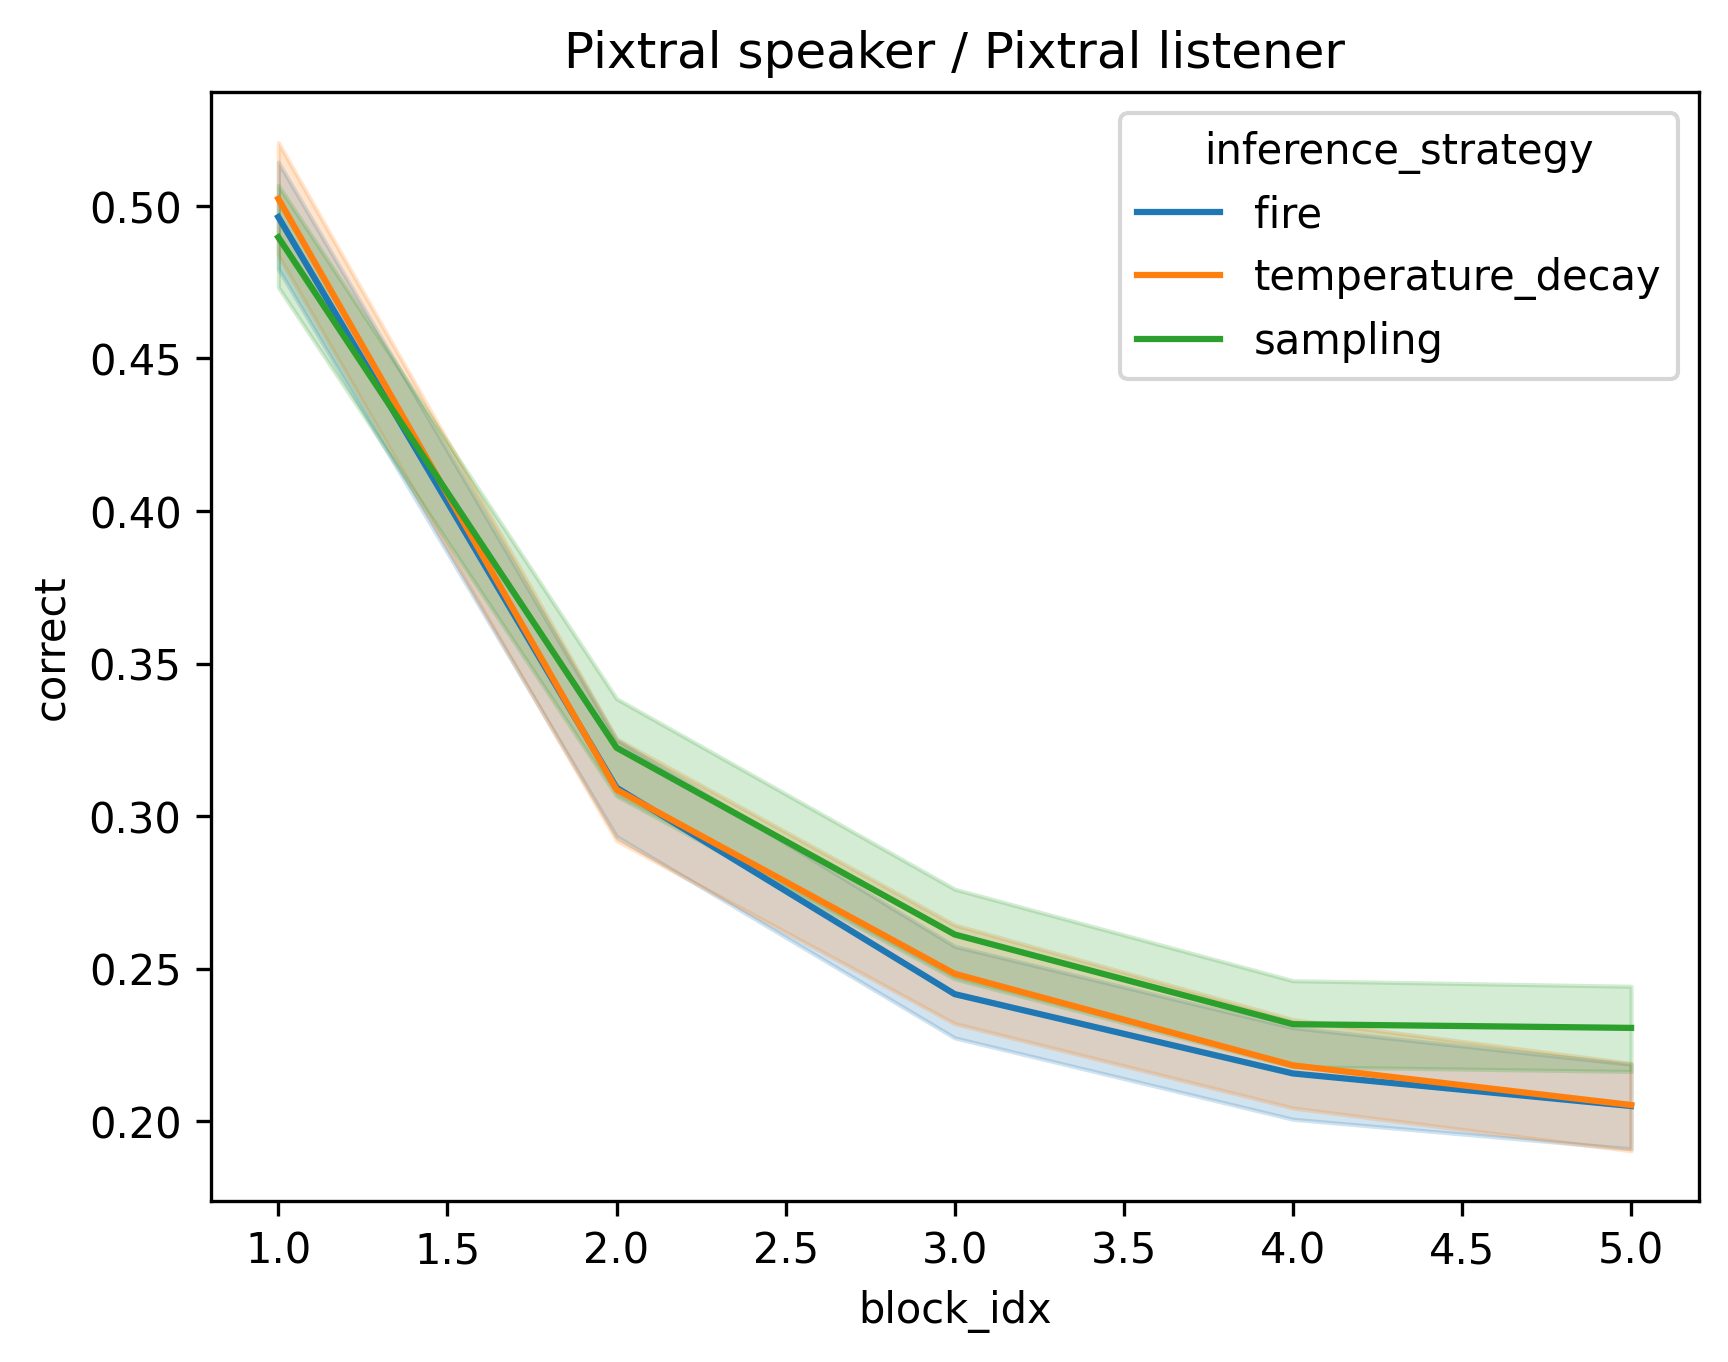

In [18]:
sns.lineplot(data=df[df.condition.isin([0, 1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 33])], x="block_idx", y="correct", hue="inference_strategy")
plt.title("Pixtral speaker / Pixtral listener")

Text(0.5, 1.0, 'Pixtral speaker / Pixtral listener')

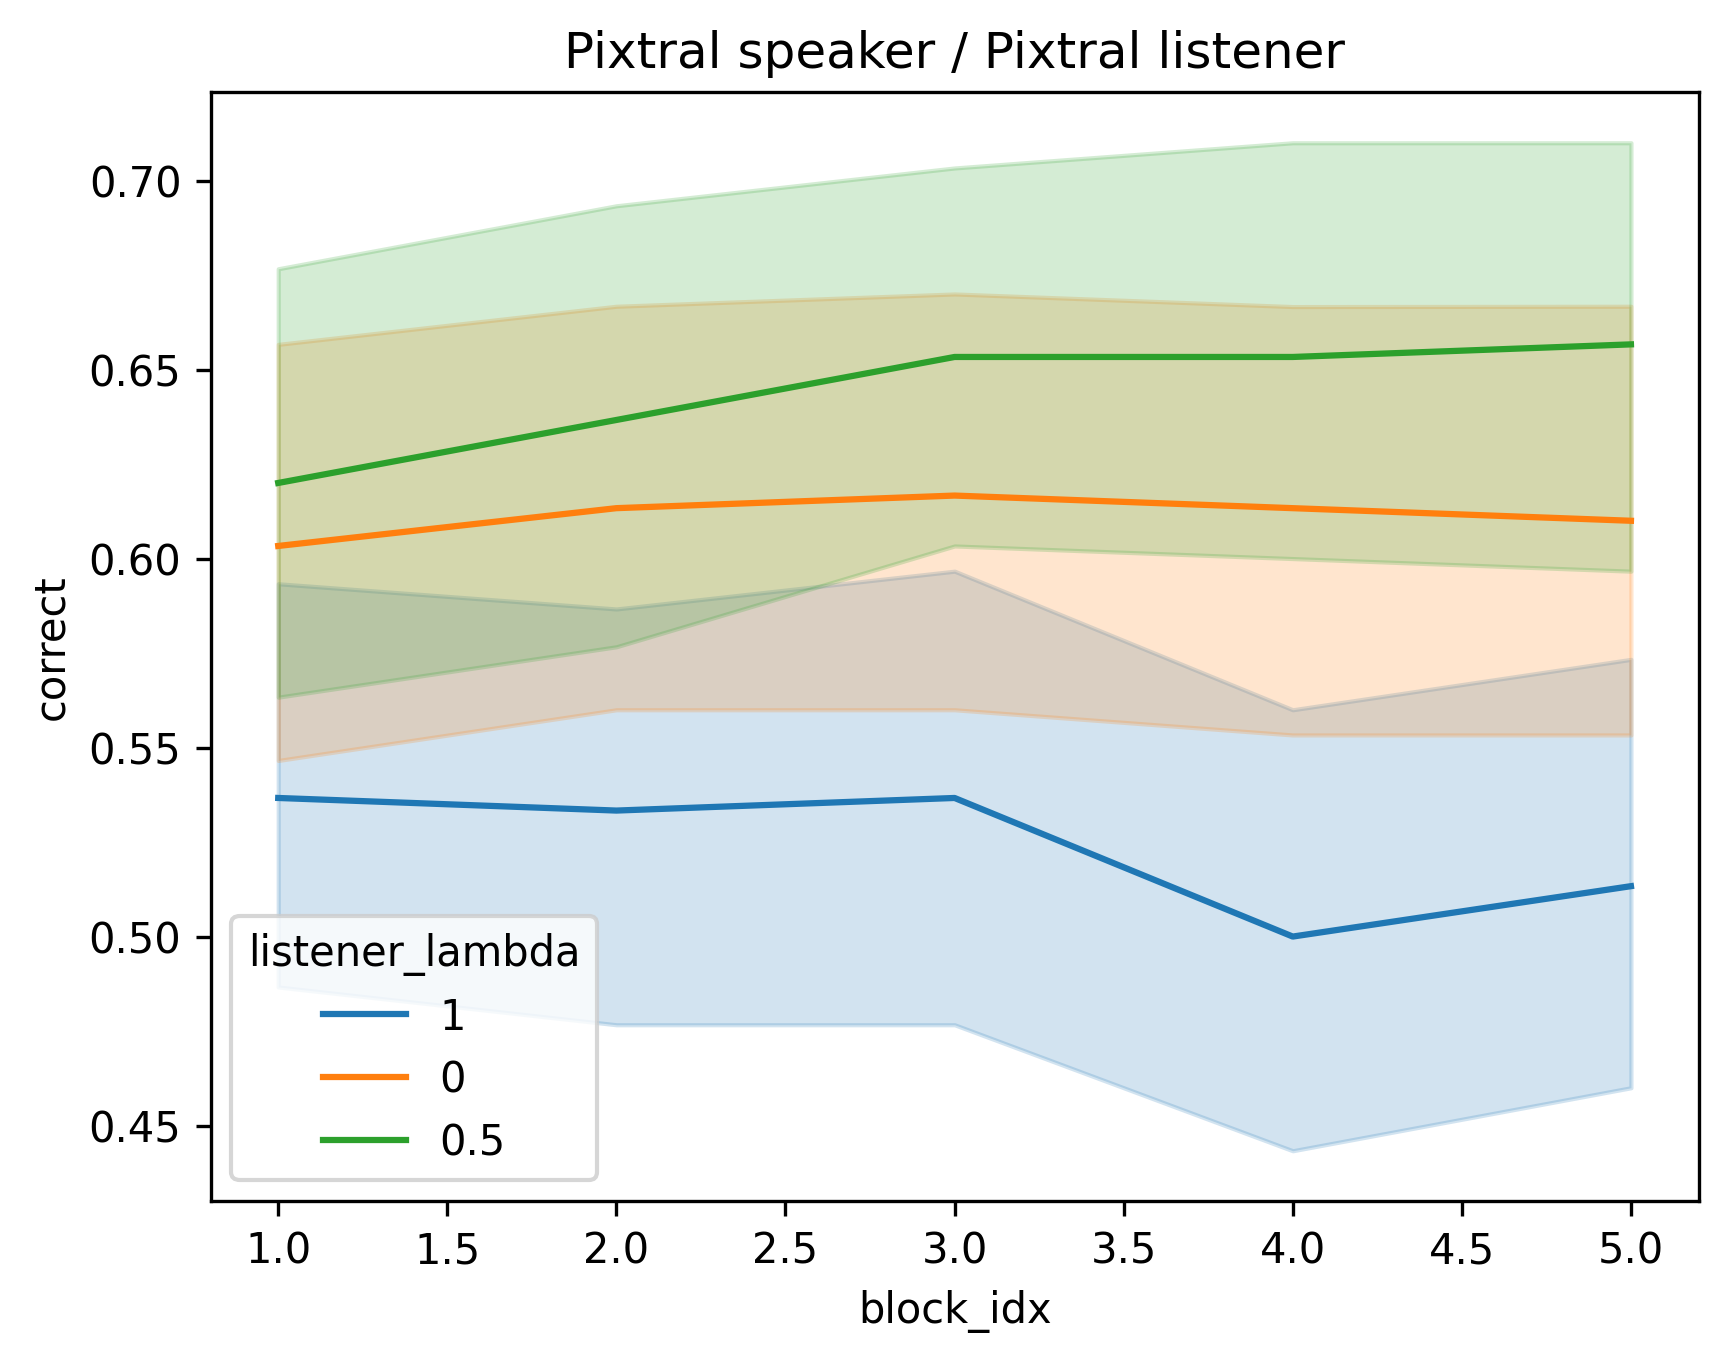

In [27]:
sns.lineplot(data=df[df.condition.isin([7, 16, 34])], x="block_idx", y="correct", hue="listener_lambda")
plt.title("Pixtral speaker / Pixtral listener")

Text(0.5, 1.0, 'Pixtral speaker / Pixtral listener')

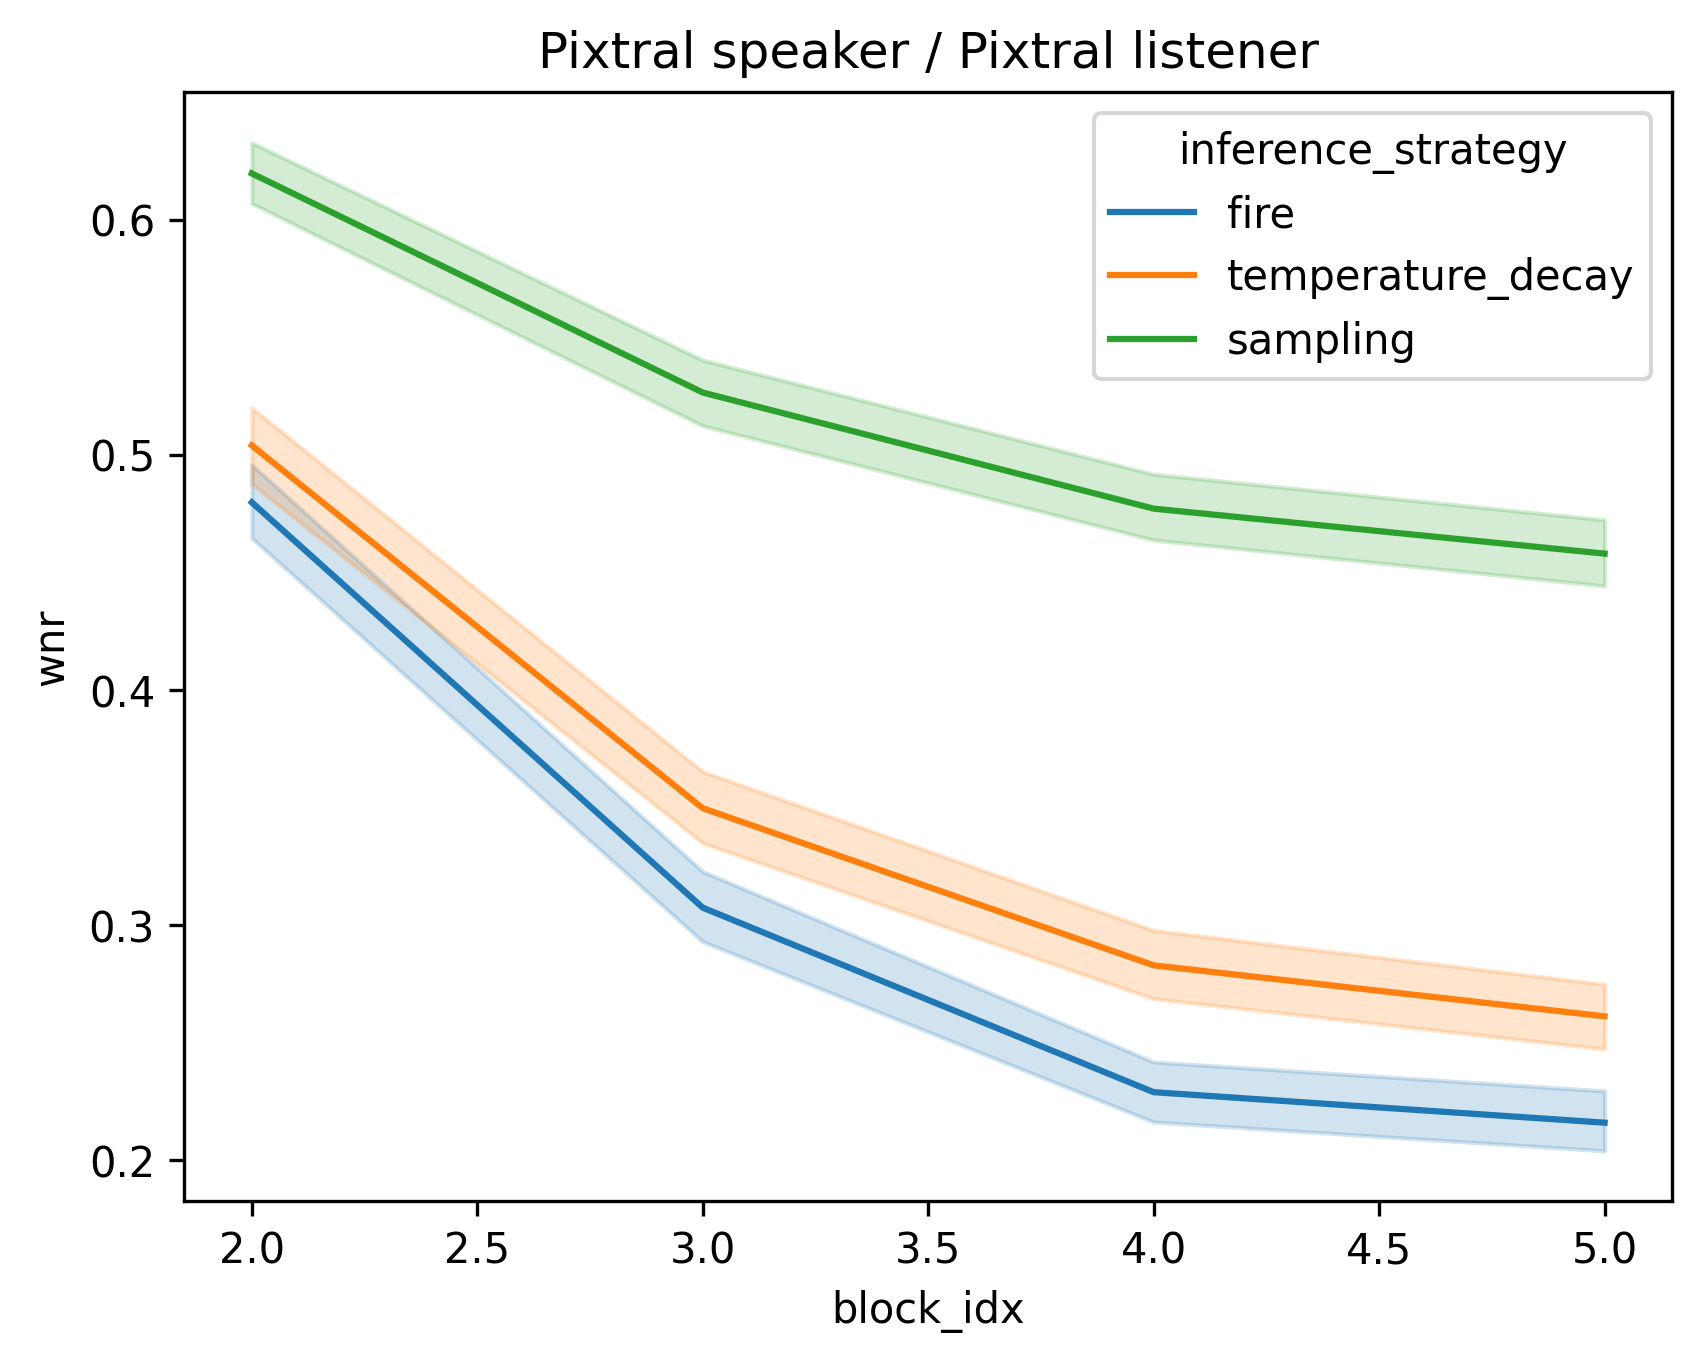

In [20]:
sns.lineplot(data=df[(df.condition.isin([0, 1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 33]))&(df.block_idx > 1)], x="block_idx", y="wnr", hue="inference_strategy")
plt.title("Pixtral speaker / Pixtral listener")

In [46]:
df[df.speaker != "human"].groupby(["gameid", "speaker", "listener", "listener_context_type", "inference_strategy", "speaker_temp", "listener_lambda", "block_idx", "target"]).apply(lambda x: snd(x['message'].values)).groupby(["inference_strategy", "speaker", "listener", "listener_lambda"]).mean()

/home/svadugur/miniconda3/envs/tangrams/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/svadugur/miniconda3/envs/tangrams/lib/python3.12/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_3624288/1156005638.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df[df.speaker != "human"].groupby(["gameid", "speaker", "listener", "listener_context_type", "inference_strategy", "speaker_temp", "listener_lambda", "block_idx", "target"]).apply(lambda x: snd(x['message'].values)).groupby(["inference

inference_strategy  speaker   listener  listener_lambda
fire                generate  generate  1.0                0.621813
sampling            generate  generate  1.0                0.703792
temperature_decay   generate  generate  1.0                0.668136
dtype: float64

In [47]:
df.kilogram_snd.mean()

np.float64(0.8175589065255731)

Text(0.5, 1.0, 'Pixtral speaker / Pixtral listener')

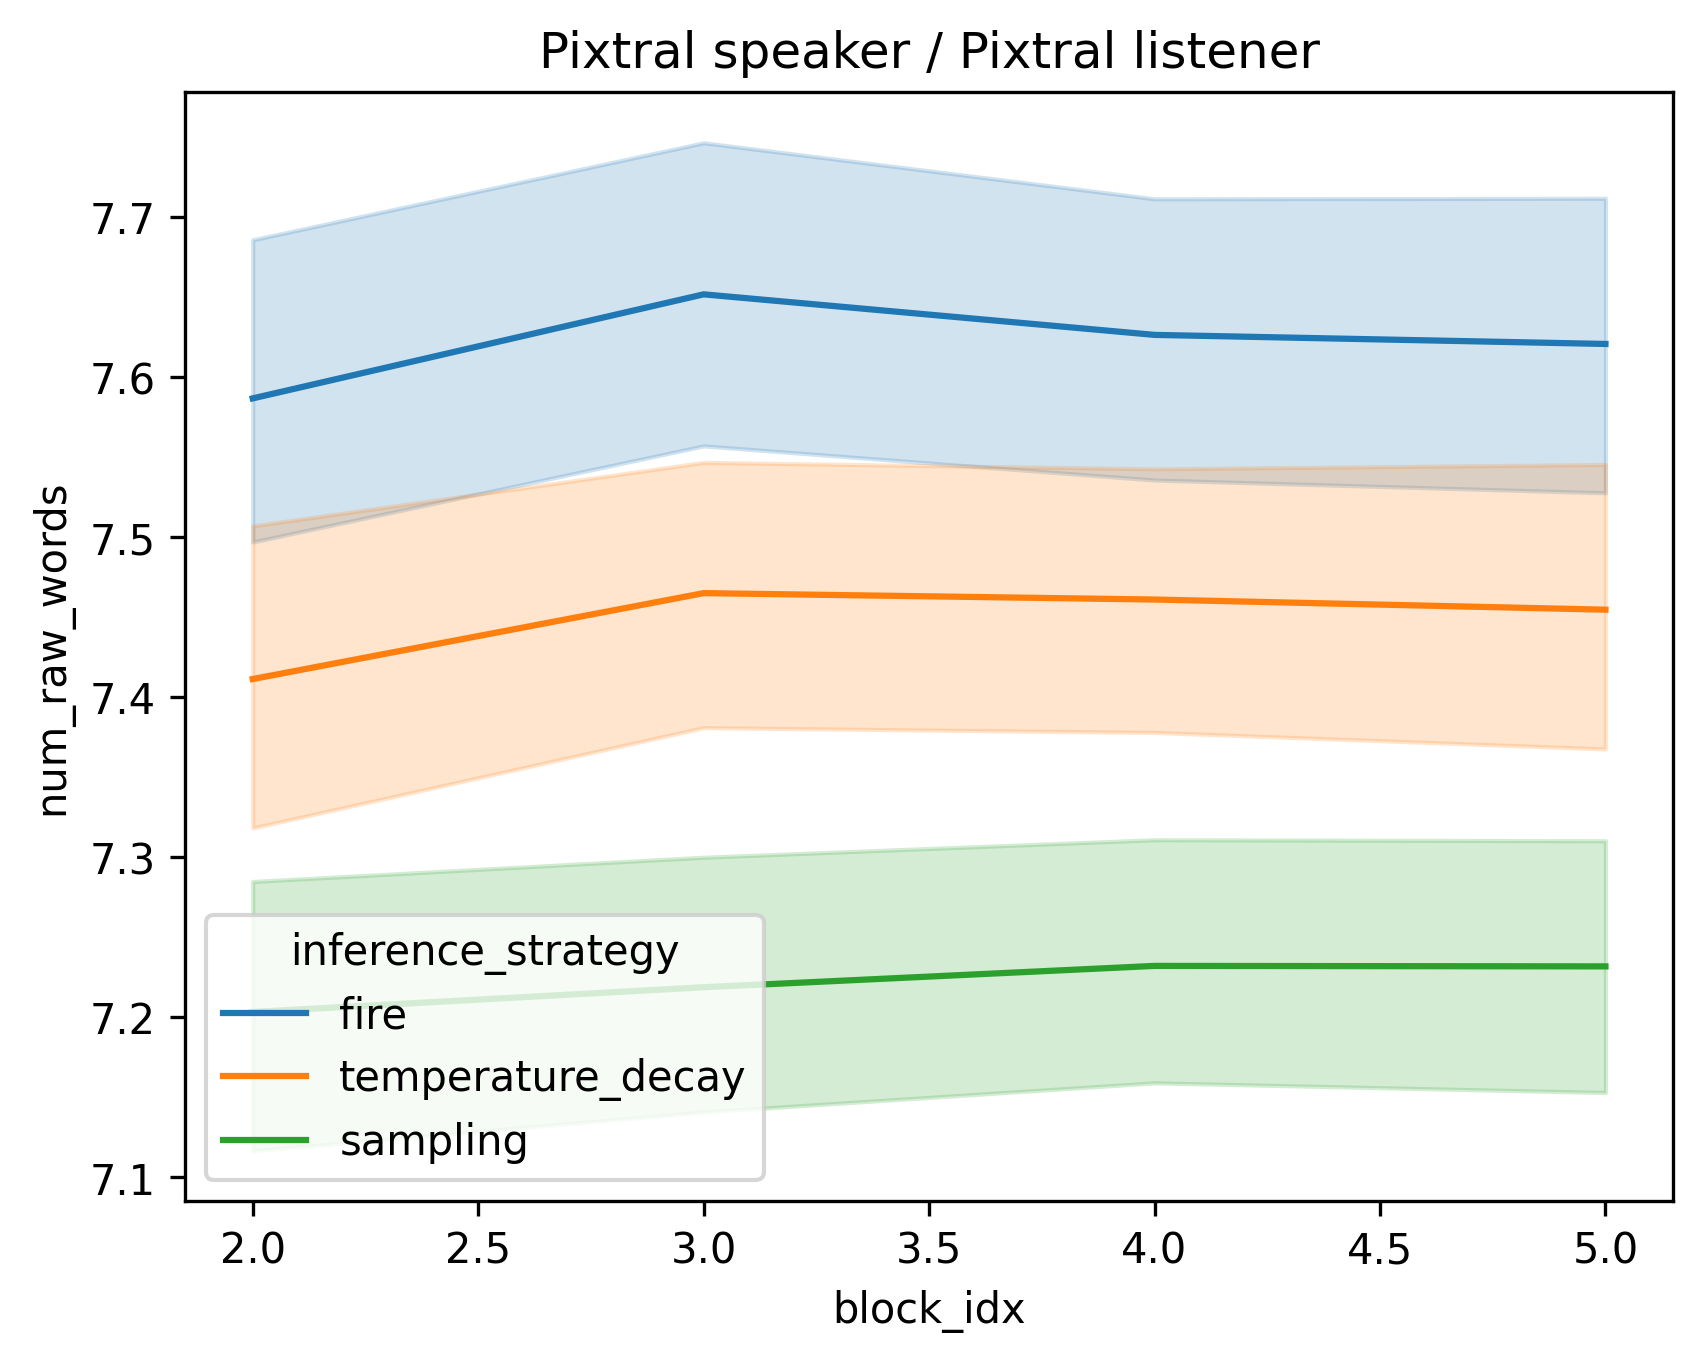

In [21]:
sns.lineplot(data=df[(df.condition.isin([0, 1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 33]))&(df.block_idx > 1)], x="block_idx", y="num_raw_words", hue="inference_strategy")
plt.title("Pixtral speaker / Pixtral listener")

Text(0.5, 1.0, 'Human speaker / Pixtral listener')

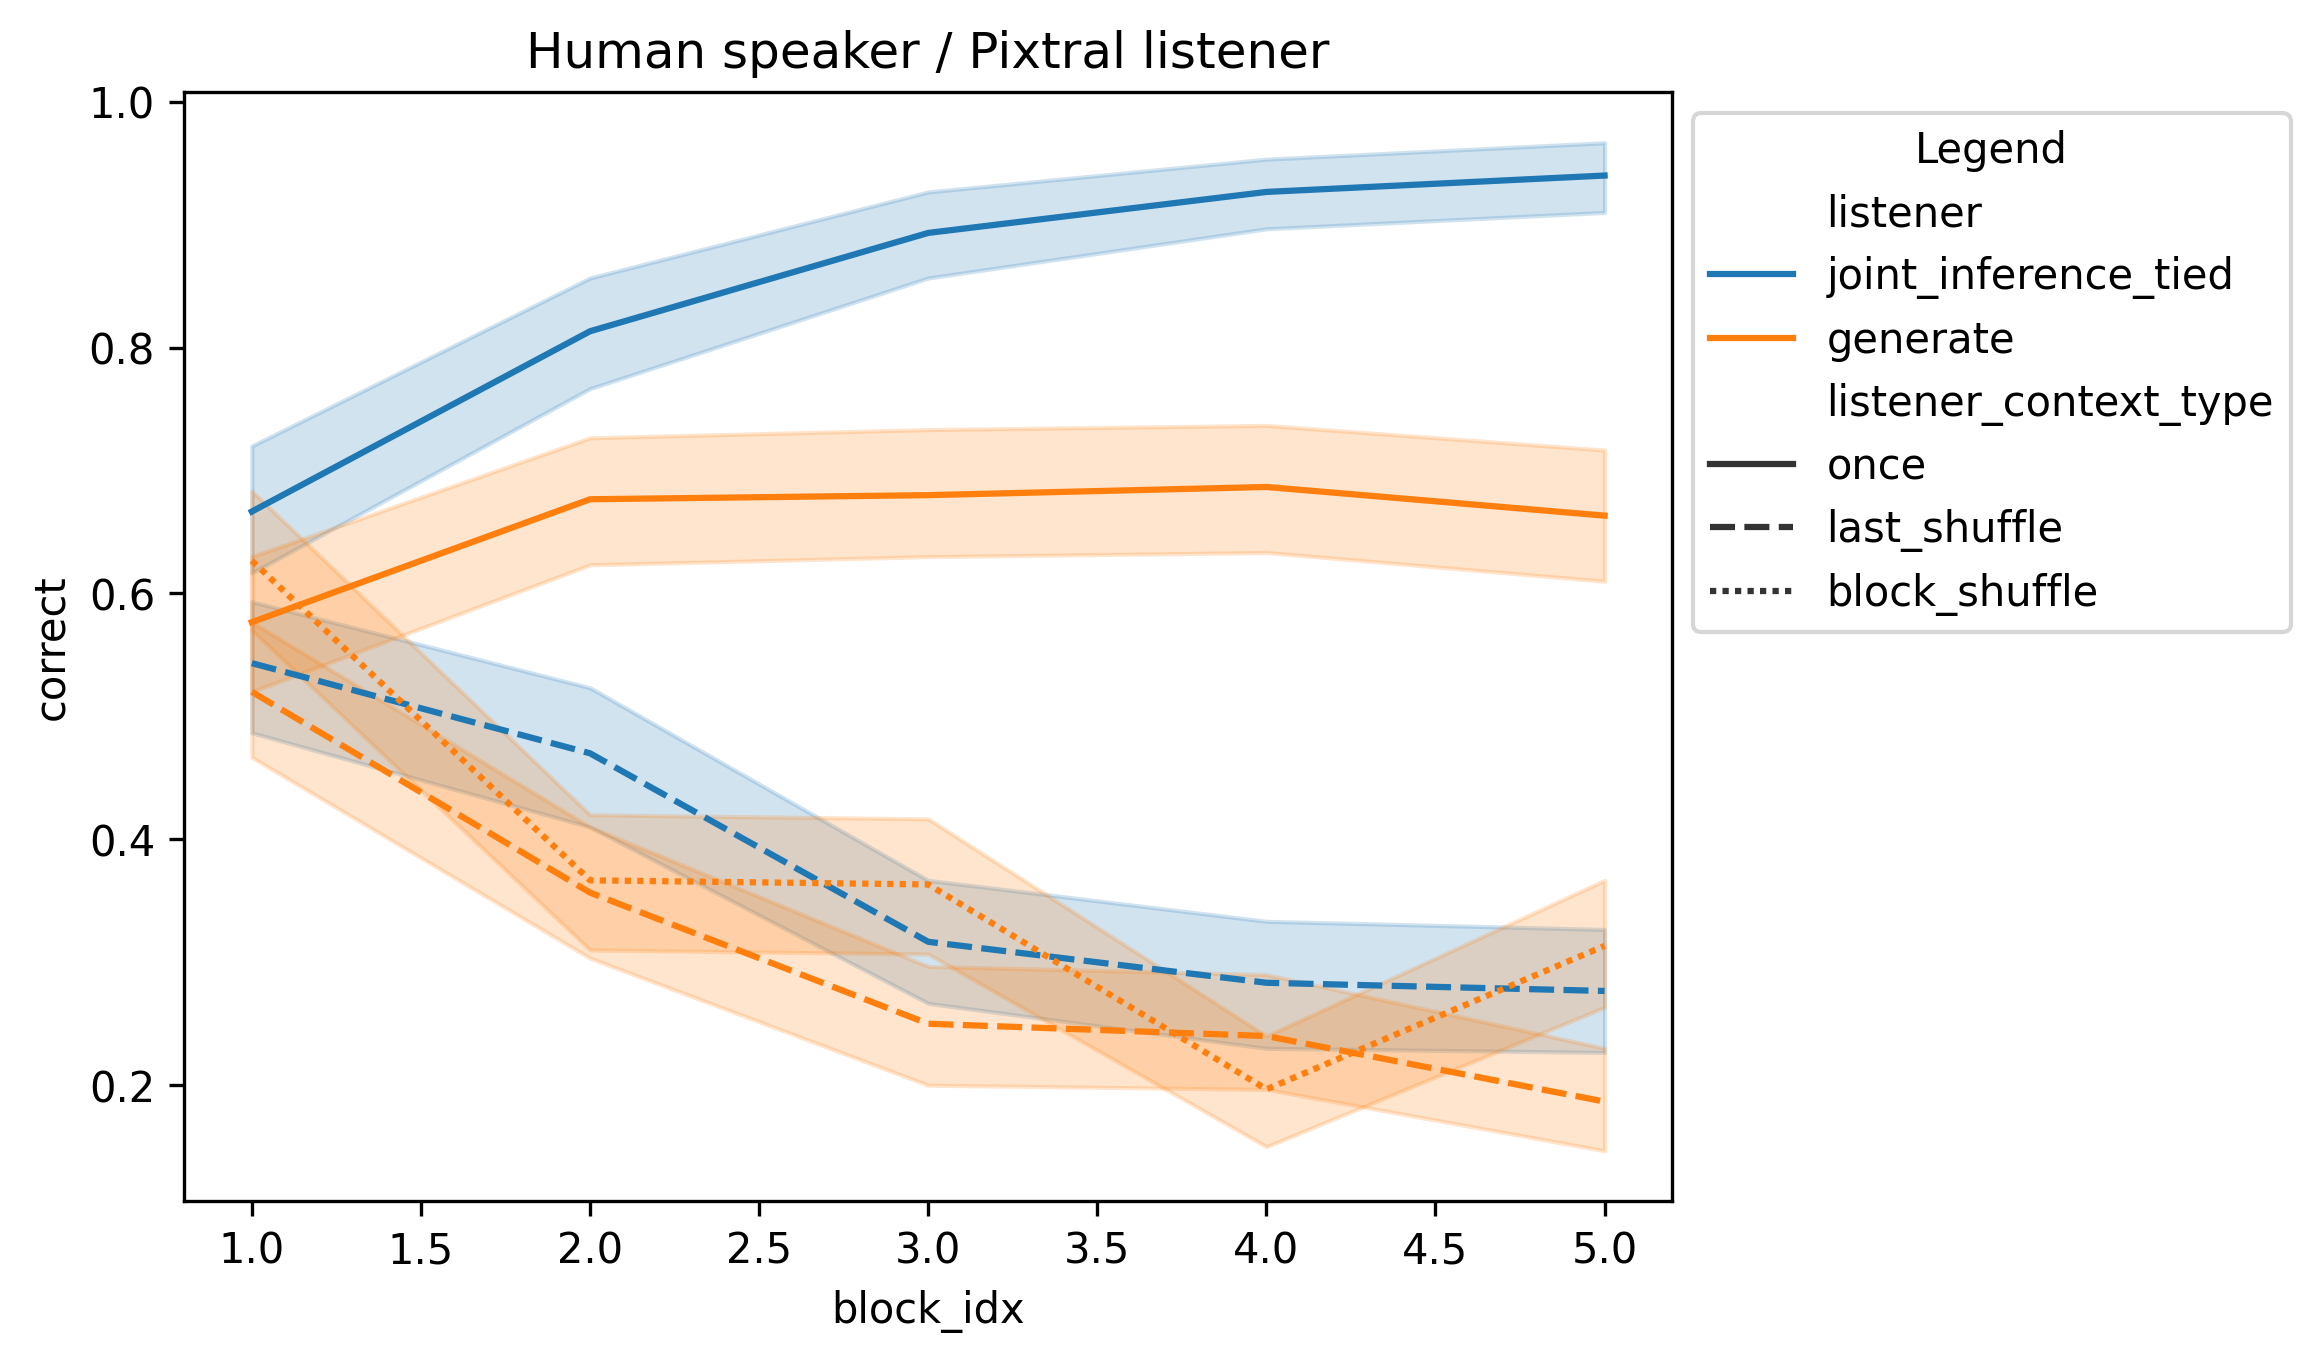

In [15]:
ax = sns.lineplot(data=df[df.condition.isin([2, 8, 9, 27, 29])], x="block_idx", y="correct", style="listener_context_type", hue="listener")
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Legend")
plt.title("Human speaker / Pixtral listener")

Text(0.5, 1.0, 'Human speaker / Pixtral listener')

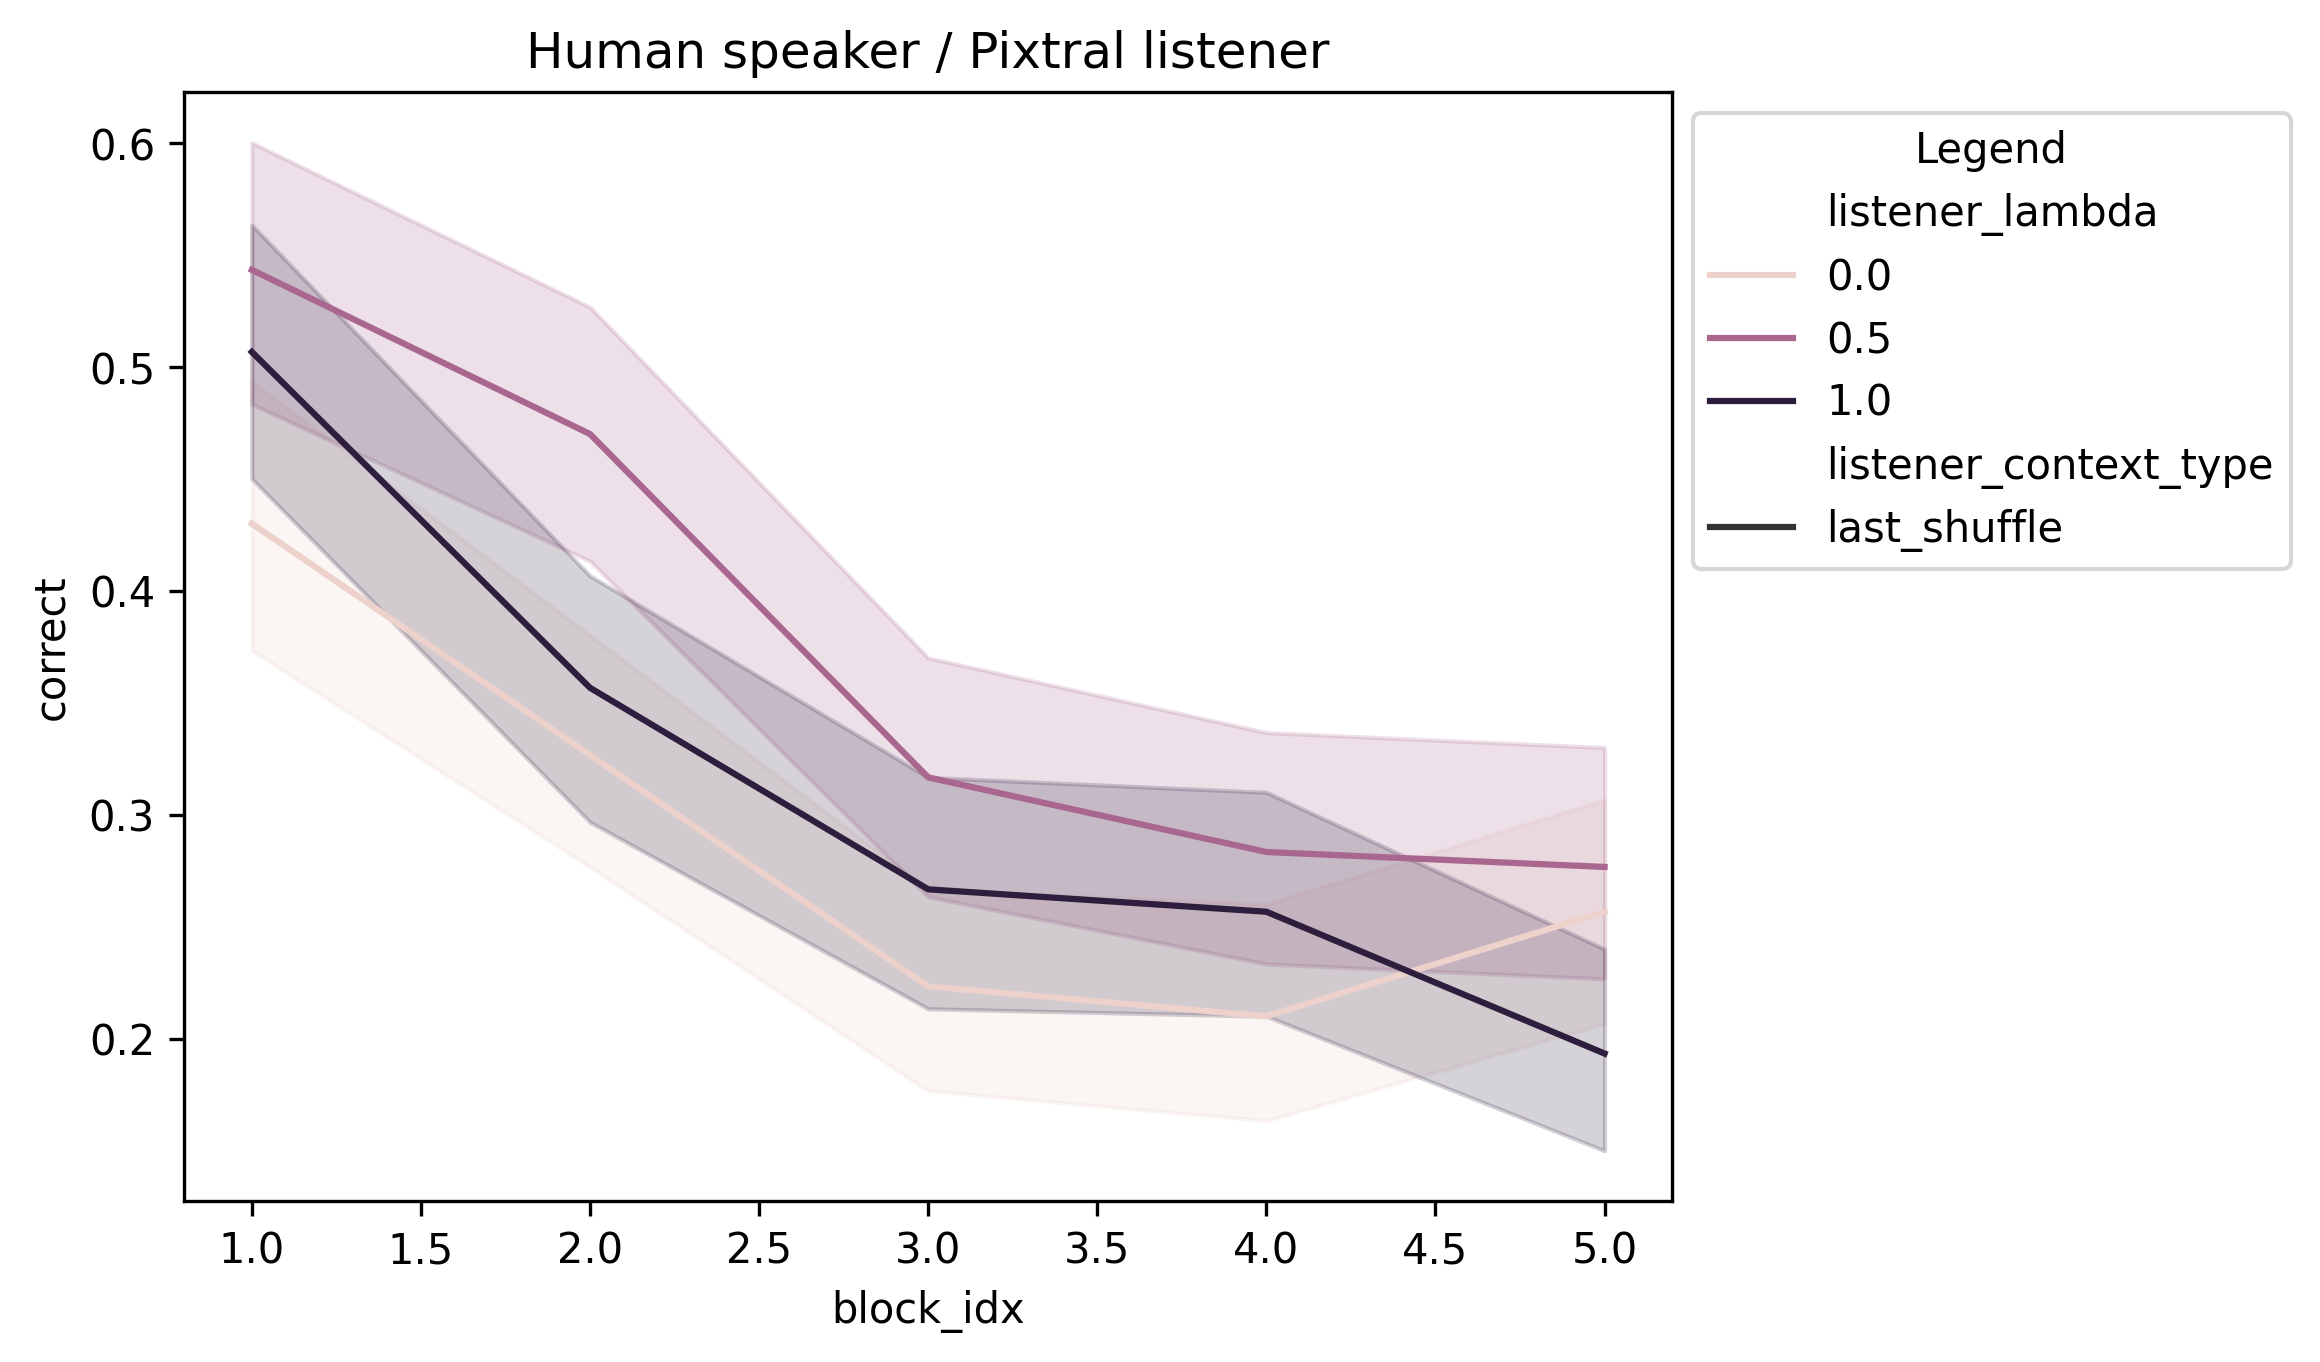

In [18]:
ax = sns.lineplot(data=df[df.condition.isin([11, 27, 48])], x="block_idx", y="correct", style="listener_context_type", hue="listener_lambda")
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Legend")
plt.title("Human speaker / Pixtral listener")

Text(0.5, 1.0, 'Pixtral speaker / Pixtral listener')

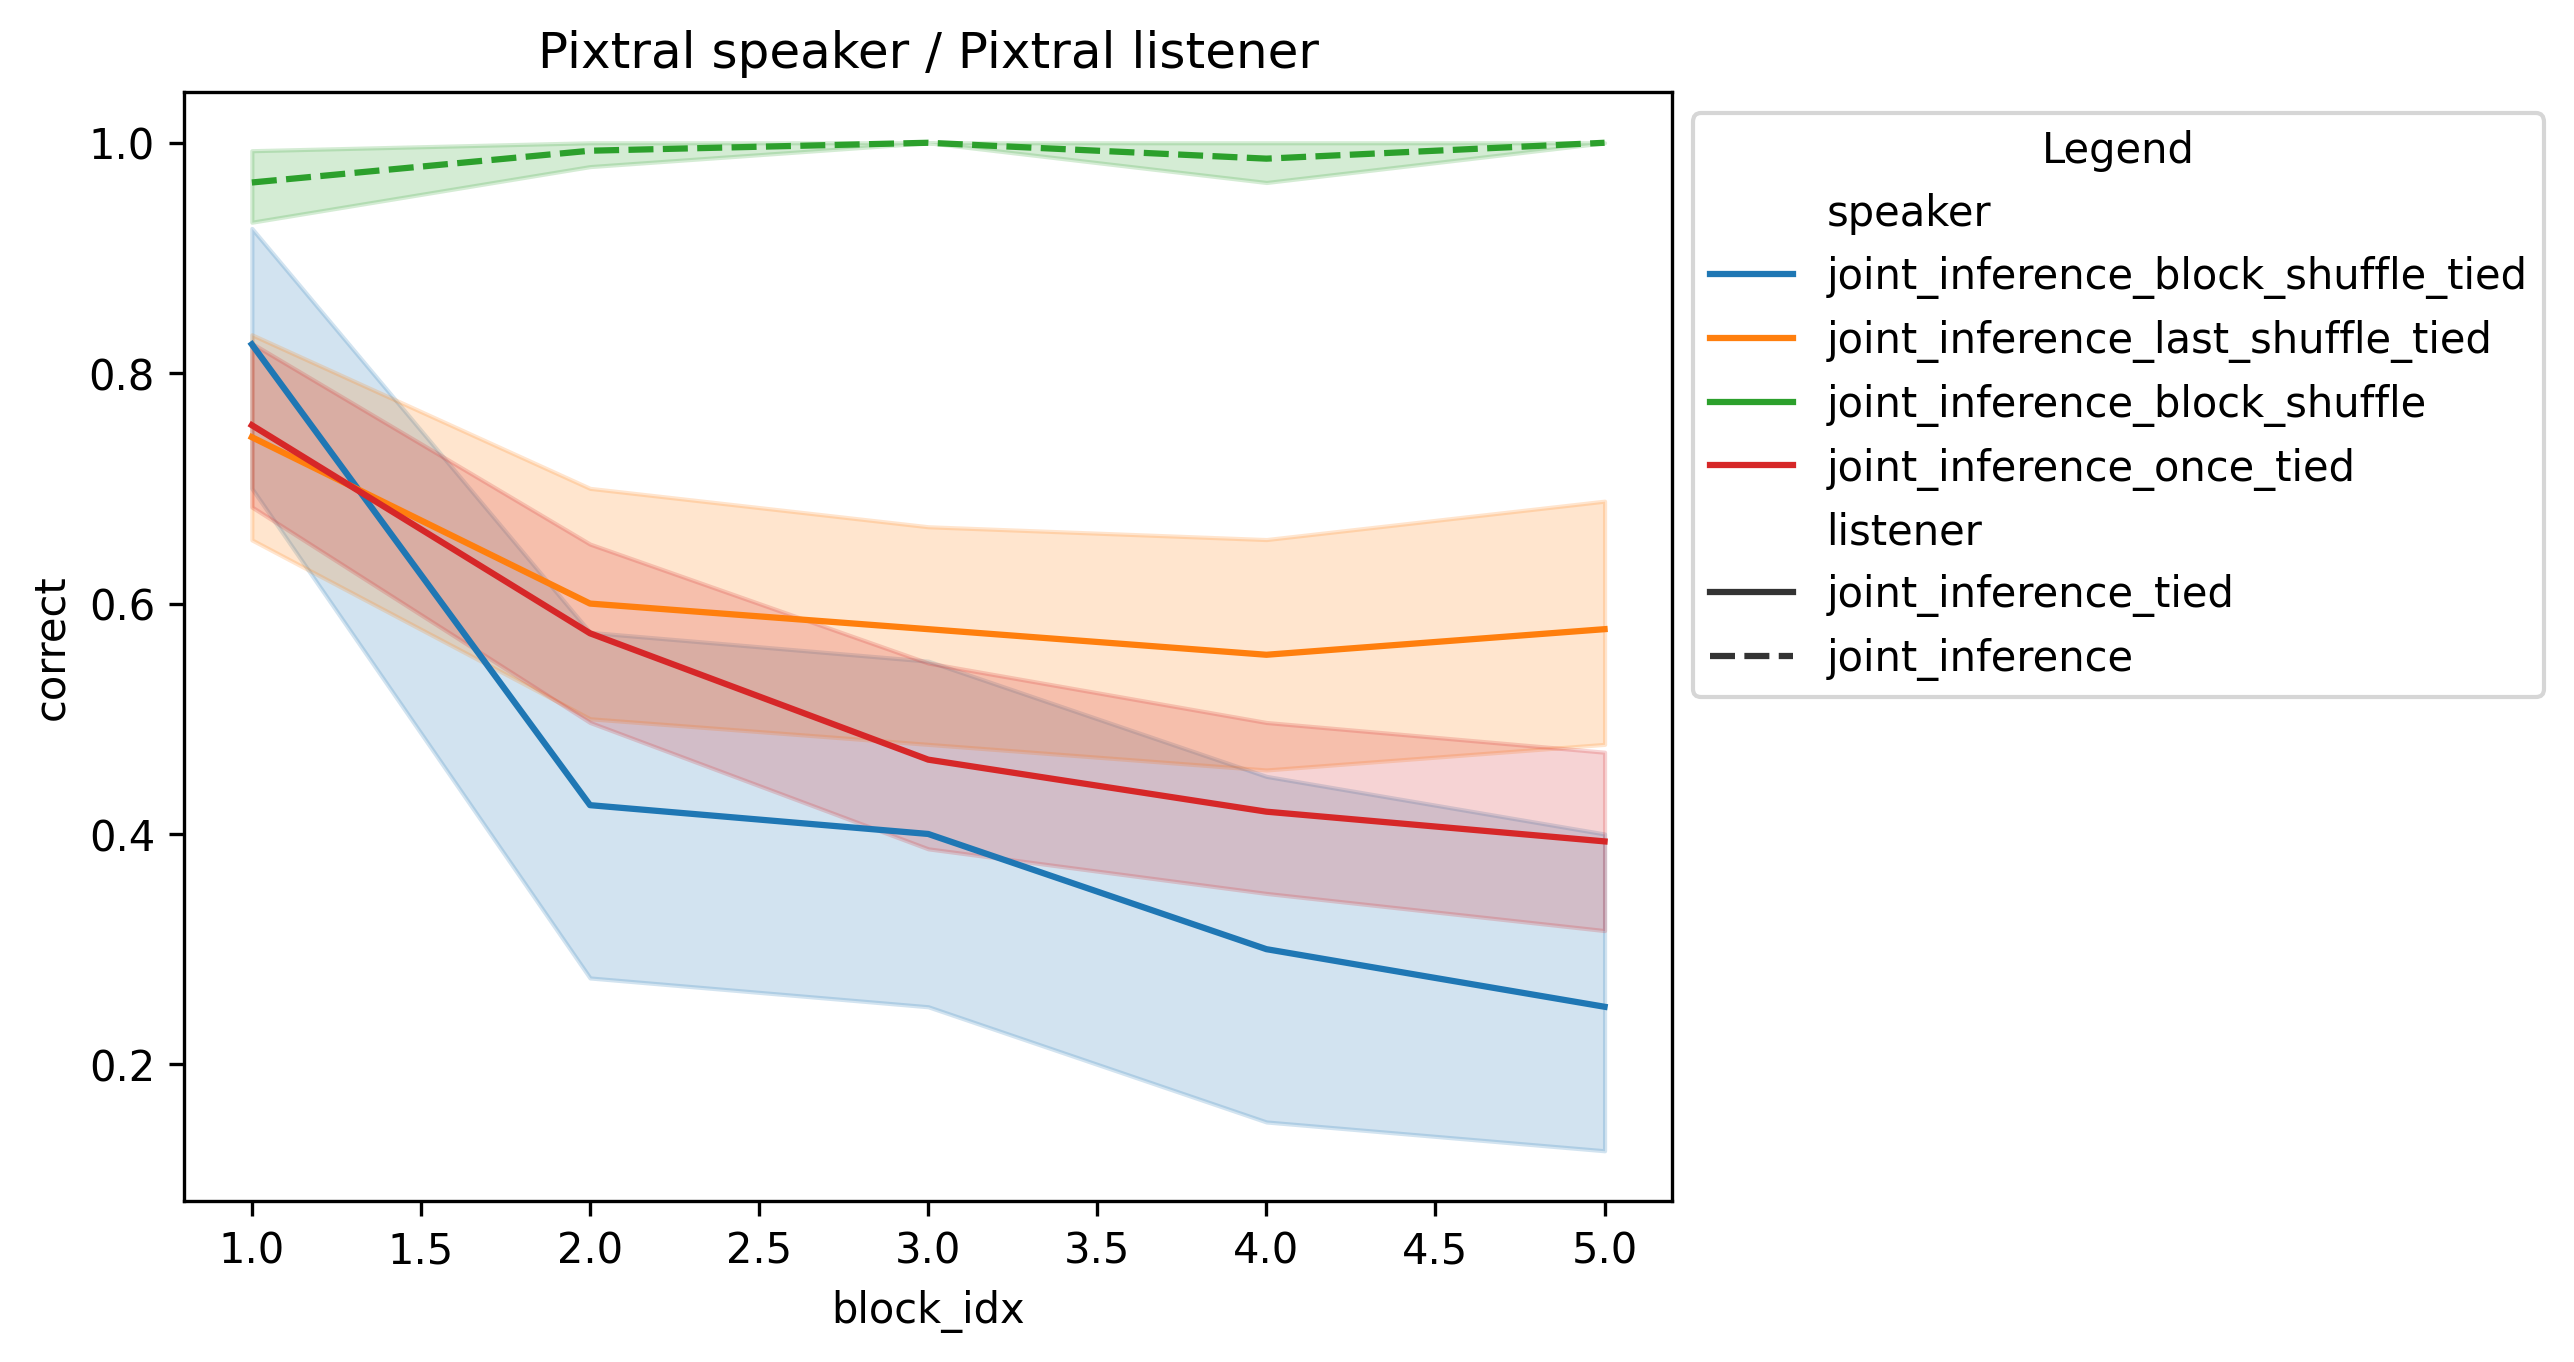

In [25]:
ax = sns.lineplot(data=df[df.condition.isin([26, 28, 47, 42])], x="block_idx", y="correct", hue="speaker", style="listener")
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Legend")
plt.title("Pixtral speaker / Pixtral listener")

In [ ]:
sns.lineplot(data=df[df.condition.isin([2, 4, 7])], x="block_idx", y="correct", hue="listener_context_type", style="prompt_type")
plt.title("Human speaker / Joint inference listener")

In [ ]:
sns.lineplot(data=df[df.condition.isin([1, 27, 10, 12, 11, 16])], x="block_idx", y="correct", style="speaker", hue="listener")
plt.title("Human speaker (spliced) / Pixtral listener")

In [ ]:
sns.lineplot(data=df[df.condition.isin([8, 12, 13, 11, 5])], x="block_idx", y="correct", hue="speaker")
plt.title("Pixtral speaker / Pixtral listener")

In [ ]:
sns.lineplot(data=df[df.condition.isin([8, 12, 13, 11, 5])], x="block_idx", y="num_raw_words", hue="speaker")
plt.title("Pixtral speaker / Pixtral listener")

In [ ]:
sns.lineplot(data=df[df.condition.isin([8, 12, 13, 11, 5])], x="block_idx", y="snd", hue="speaker")
plt.title("Pixtral speaker / Pixtral listener")

In [ ]:
custom_palette = sns.color_palette("viridis", 12)
ax = sns.lineplot(data=df[df.condition.isin([ 2,  4,  5,  8, 13, 17, 20, 28, 30, 36, 40, 7])], x="block_idx", y="correct", hue="listener_lambda", style="listener", palette=custom_palette)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Legend")
ax.set_title("Human speaker / Pixtral listener")

In [ ]:
custom_palette = sns.color_palette("viridis", 12)
ax = sns.lineplot(data=df[df.condition.isin([ 9, 15, 24, 25, 29, 38])], x="block_idx", y="correct", hue="listener_lambda", style="listener", palette=custom_palette)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Legend")
ax.set_title("Joint inference speaker / Joint inference listener")

In [ ]:
custom_palette = sns.color_palette("viridis", 12)
sns.lineplot(data=df[df.condition.isin([ 0, 19, 31, 35])], x="block_idx", y="num_raw_words", hue="speaker_temp", palette=custom_palette, legend=False)
plt.gca().legend(loc='upper left', bbox_to_anchor=(1, 1), title="Legend")
plt.gca().set_title("Joint inference speaker / Joint inference listener")

Text(0.5, 1.0, 'Joint inference speaker / Joint inference listener')

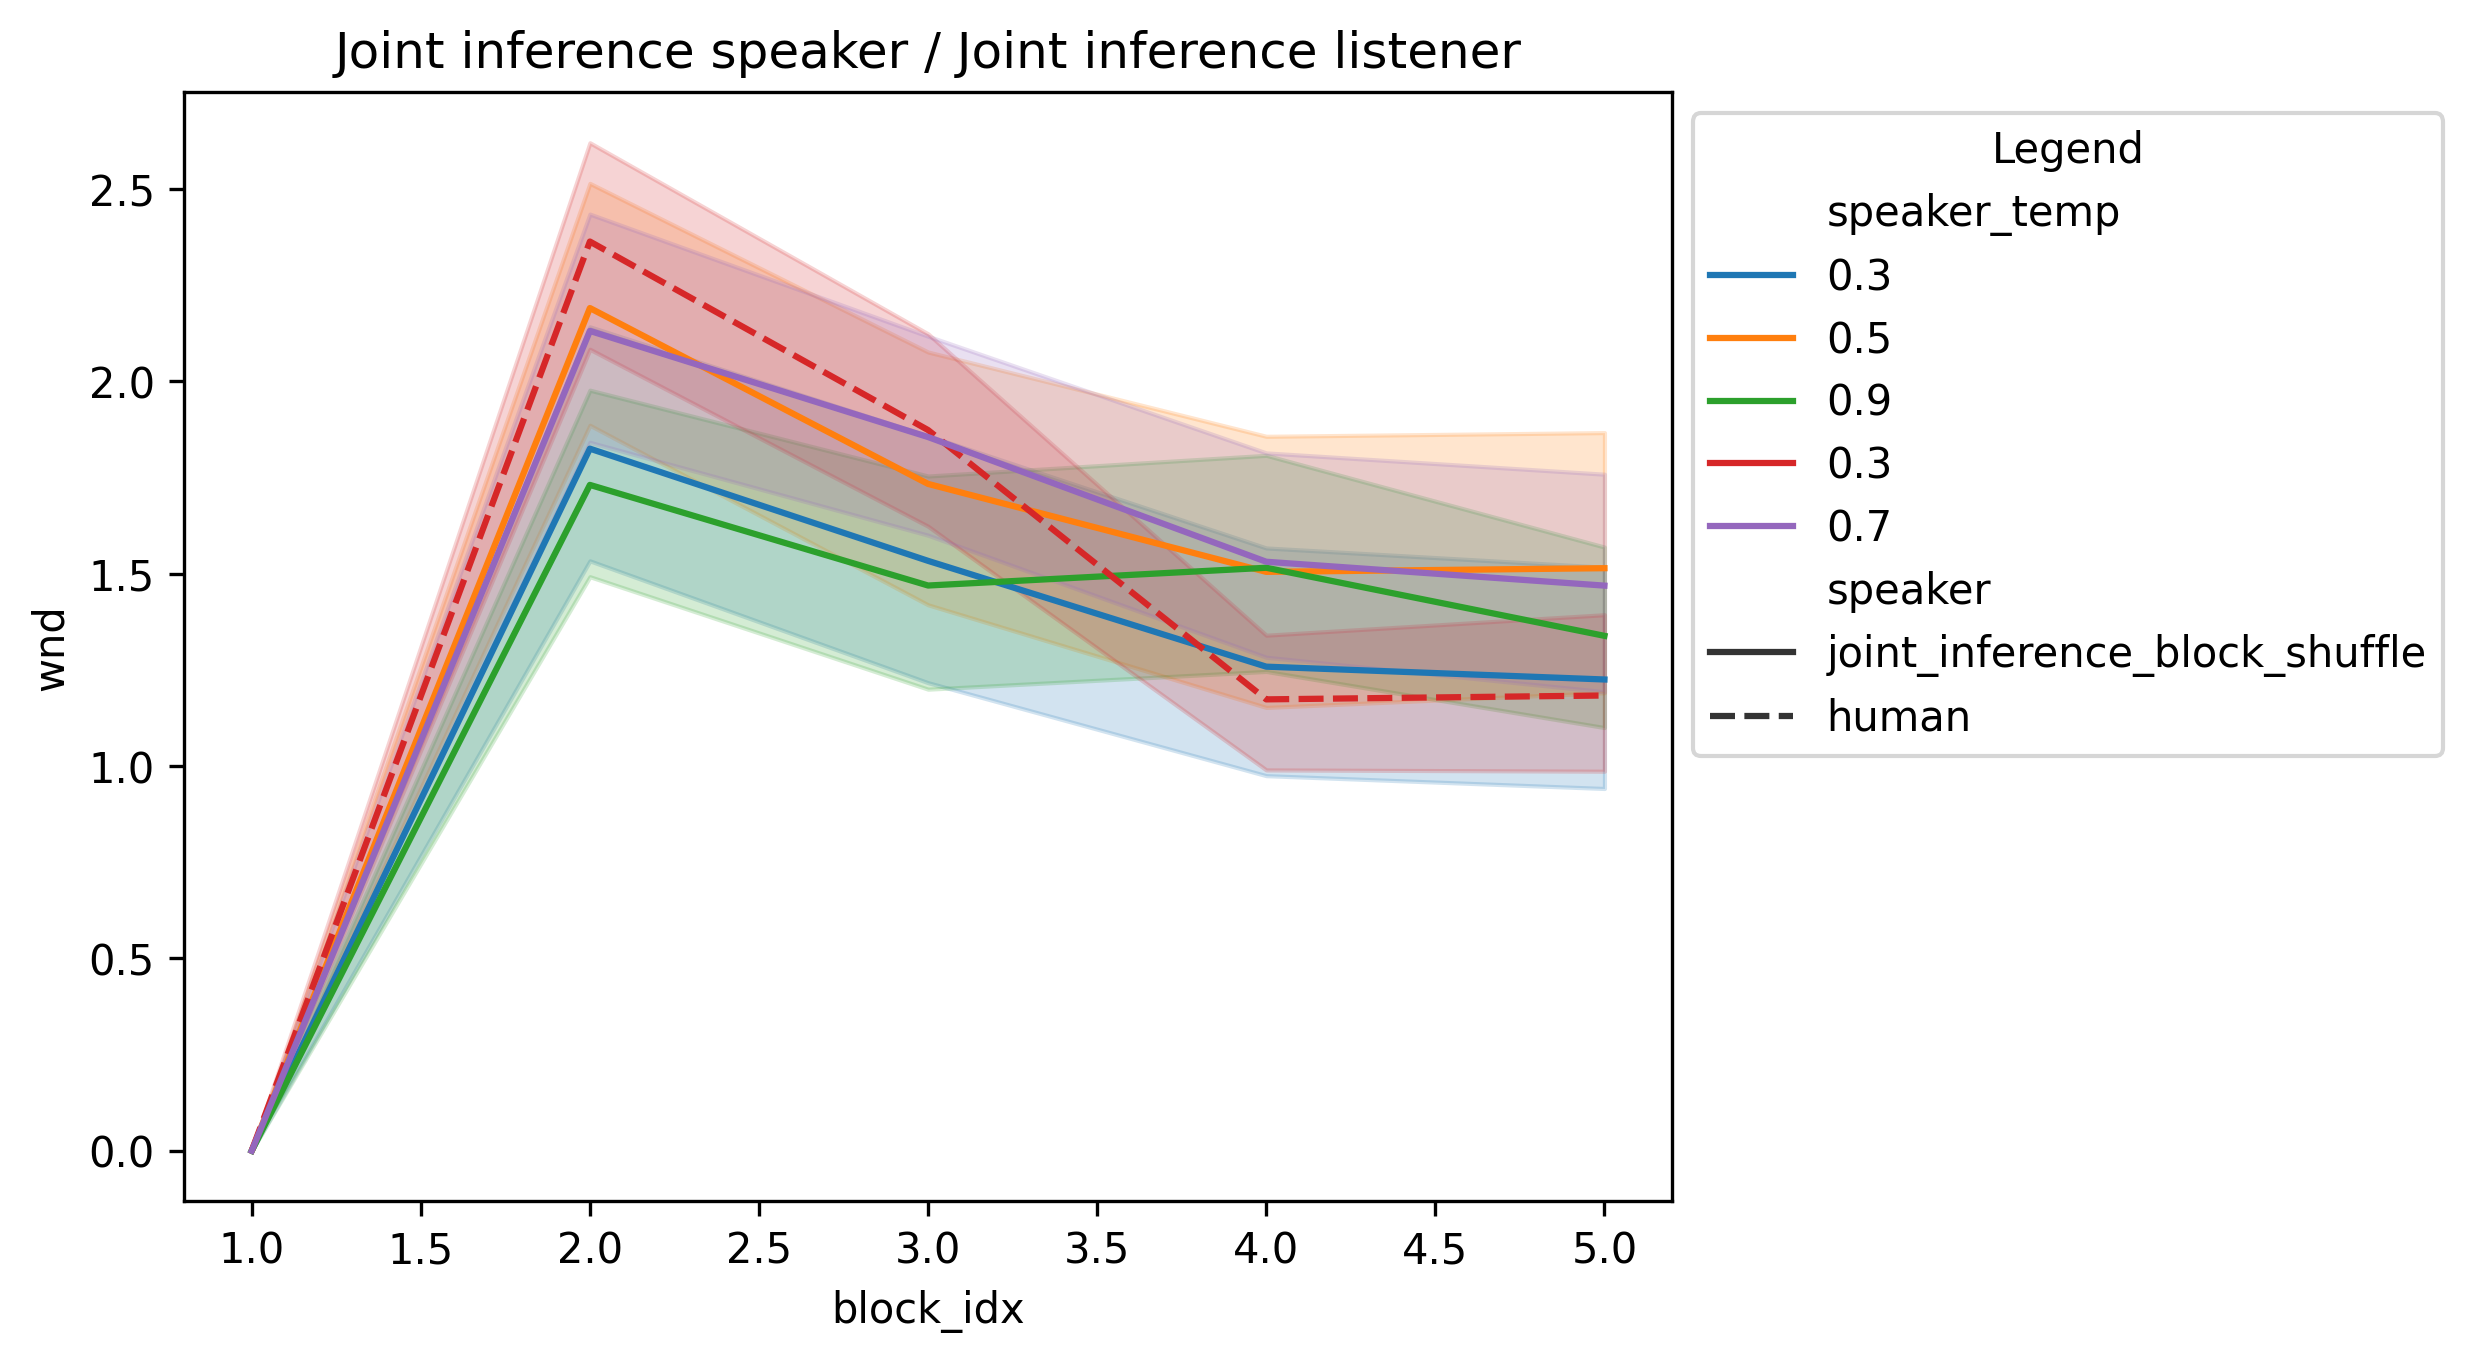

In [35]:
custom_palette = sns.color_palette("viridis", 12)
sns.lineplot(data=df[df.condition.isin([ 0, 23, 38, 42, 41])], x="block_idx", y="wnd", hue="speaker_temp", palette="tab10", style="speaker")
plt.gca().legend(loc='upper left', bbox_to_anchor=(1, 1), title="Legend")
plt.gca().set_title("Joint inference speaker / Joint inference listener")

/tmp/ipykernel_3390391/2968248124.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sns.lineplot(data=df[df.block_idx > 1][df.condition.isin([41, 26, 28, 47, 25, 4])], x="block_idx", y="wnr", hue="speaker", palette="tab10")


Text(0.5, 1.0, 'Joint inference speaker / Joint inference listener')

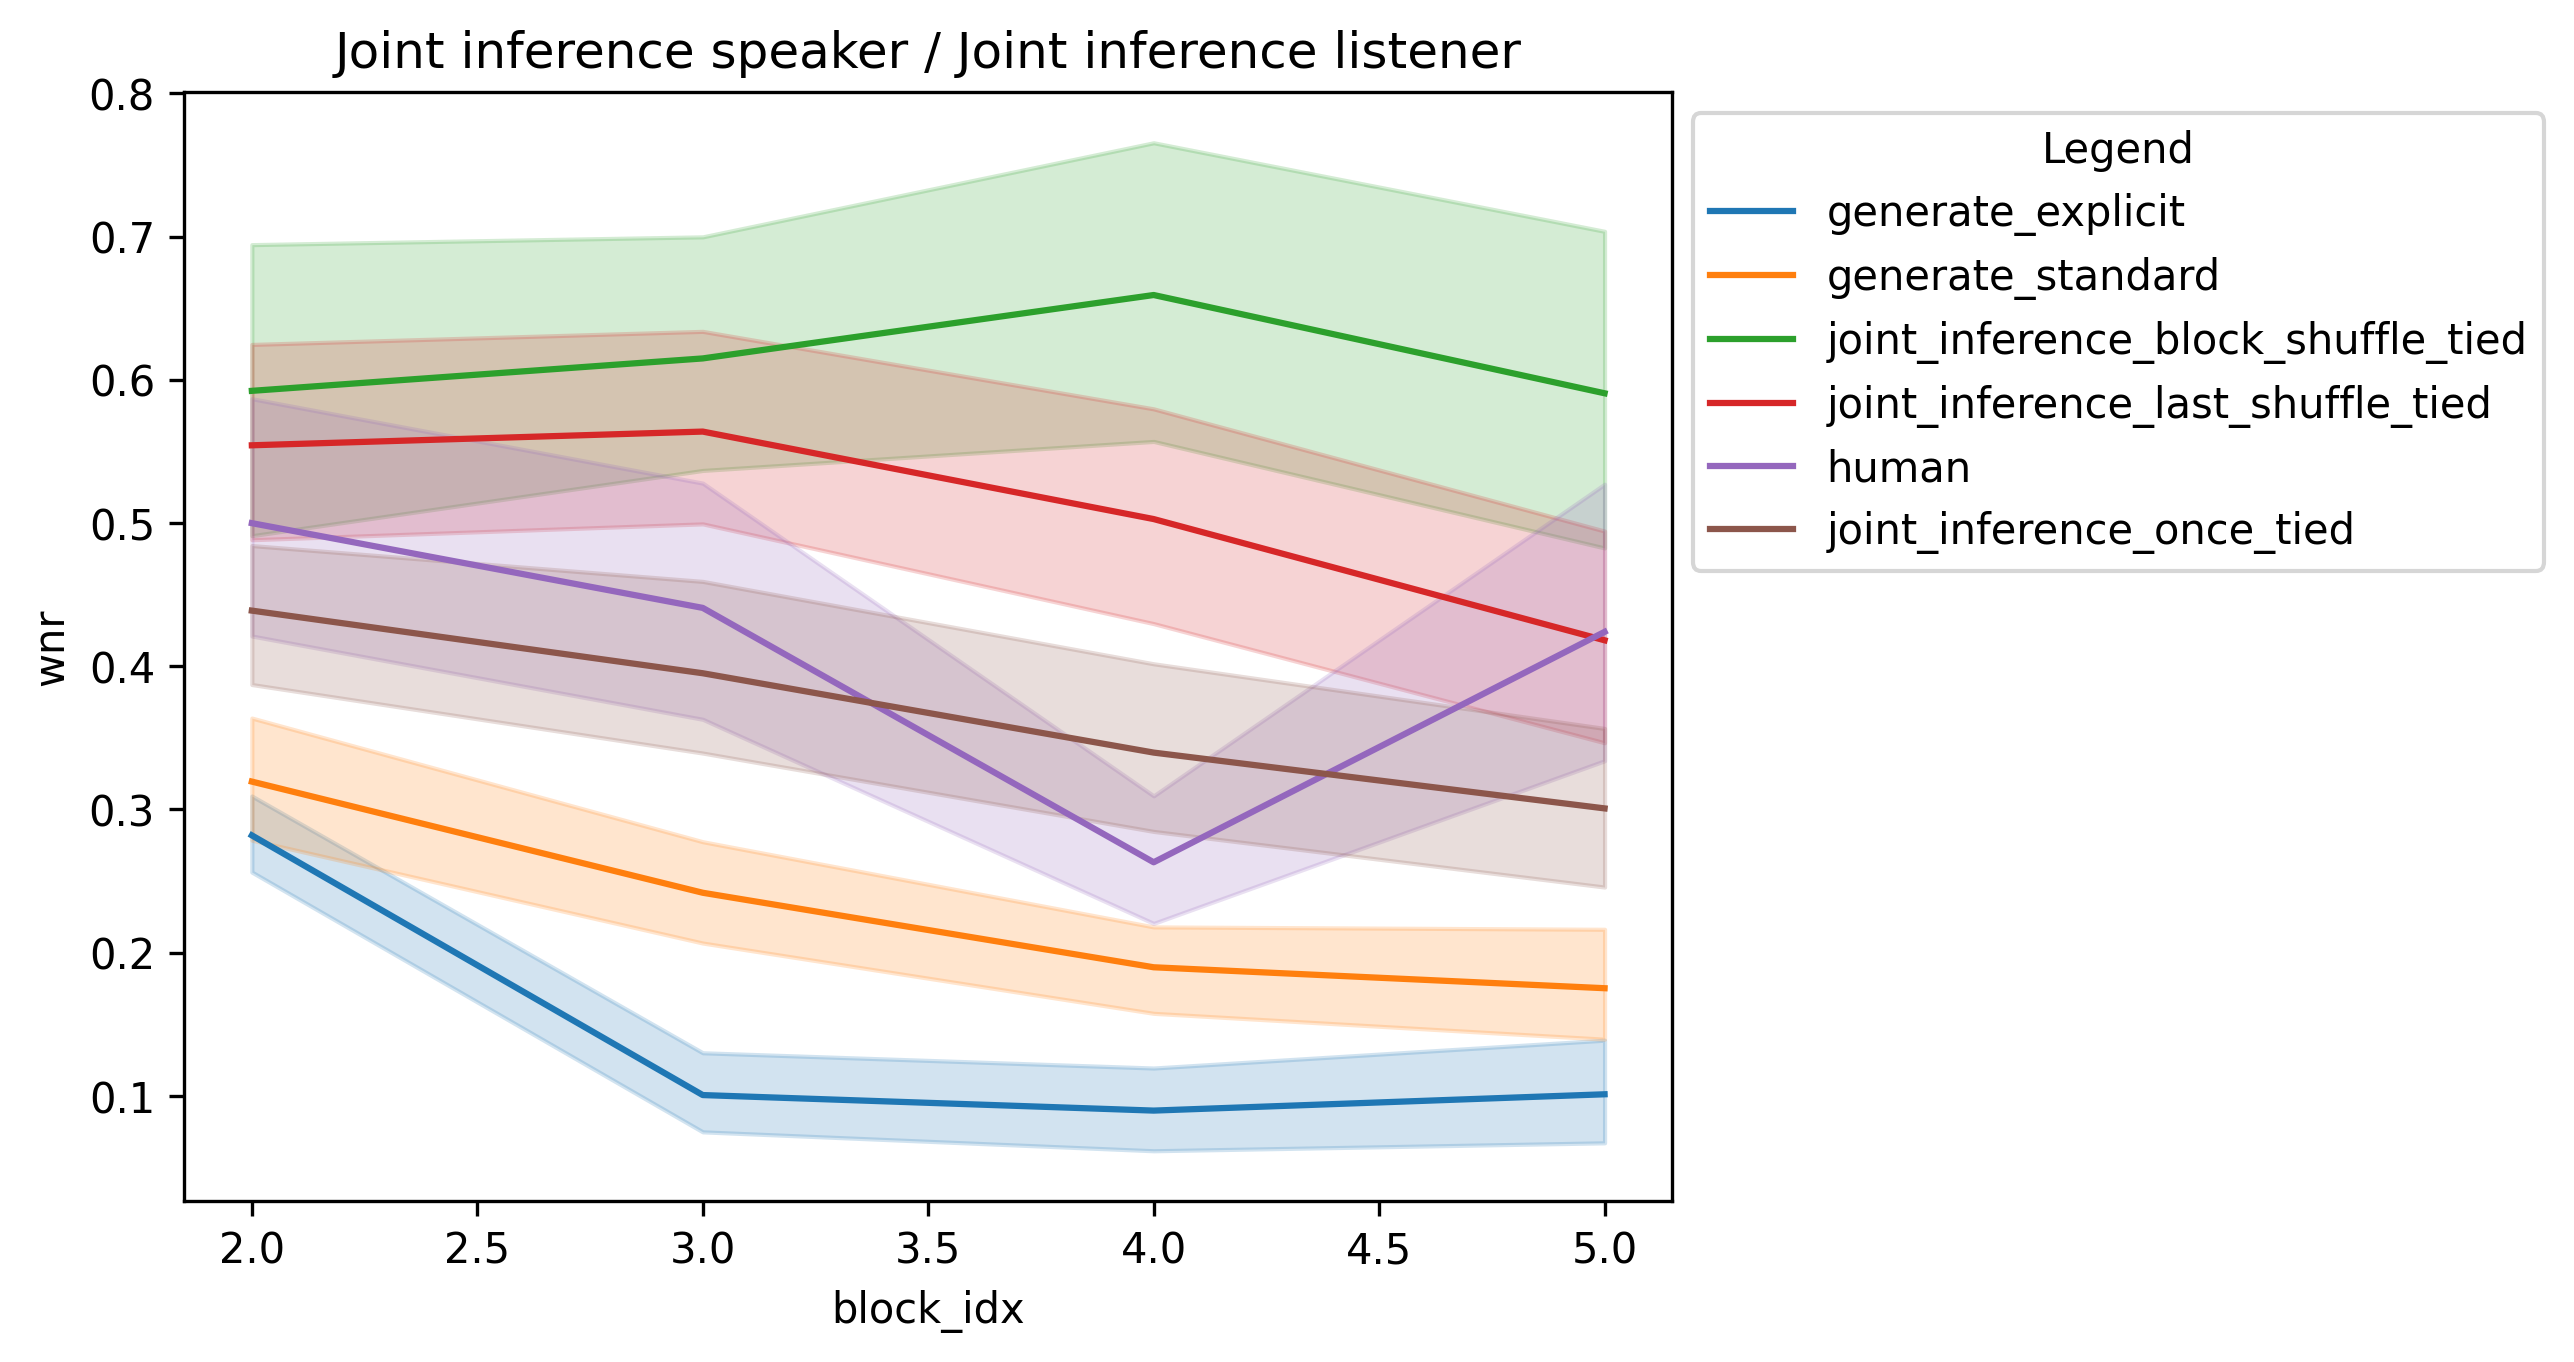

In [47]:
custom_palette = sns.color_palette("viridis", 12)
sns.lineplot(data=df[df.block_idx > 1][df.condition.isin([41, 26, 28, 47, 25, 4])], x="block_idx", y="wnr", hue="speaker", palette="tab10")
plt.gca().legend(loc='upper left', bbox_to_anchor=(1, 1), title="Legend")
plt.gca().set_title("Joint inference speaker / Joint inference listener")

/tmp/ipykernel_3390391/1608261587.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sns.lineplot(data=df[df.block_idx > 1][df.condition.isin([41, 26, 28, 47, 25, 4])], x="block_idx", y="num_raw_words", hue="speaker", palette="tab10")


Text(0.5, 1.0, 'Joint inference speaker / Joint inference listener')

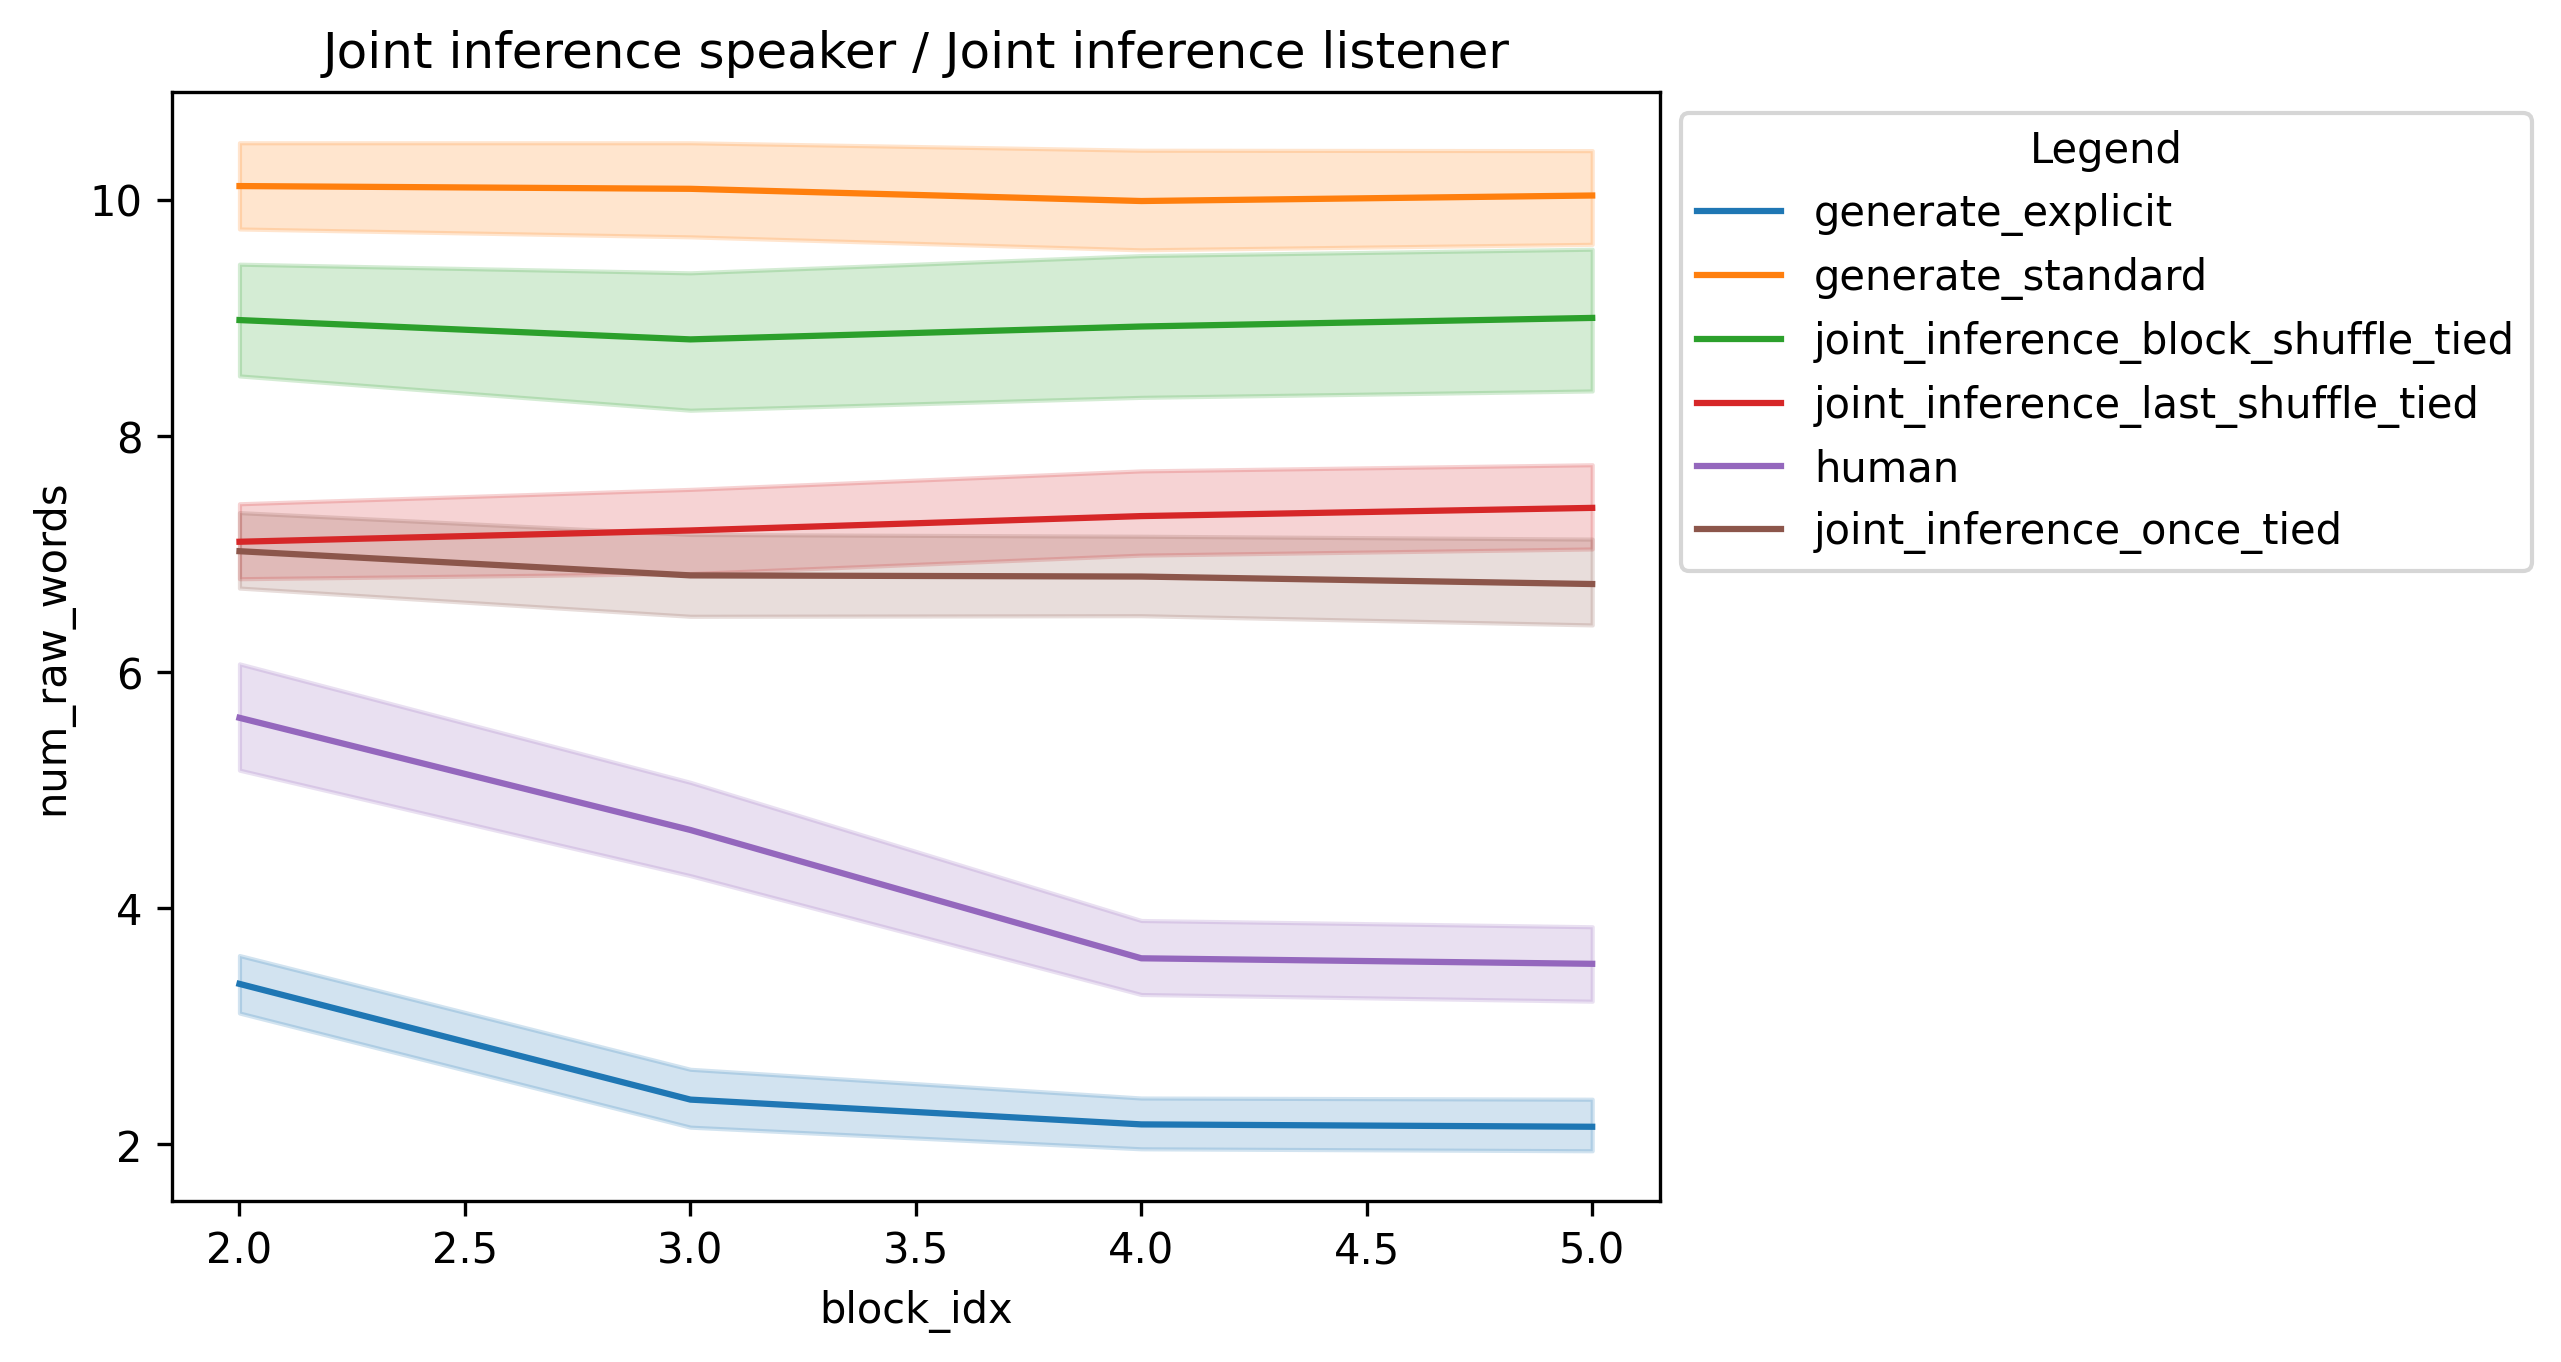

In [46]:
custom_palette = sns.color_palette("viridis", 12)
sns.lineplot(data=df[df.block_idx > 1][df.condition.isin([41, 26, 28, 47, 25, 4])], x="block_idx", y="num_raw_words", hue="speaker", palette="tab10")
plt.gca().legend(loc='upper left', bbox_to_anchor=(1, 1), title="Legend")
plt.gca().set_title("Joint inference speaker / Joint inference listener")

In [ ]:
custom_palette = sns.color_palette("viridis", 12)
sns.lmplot(data=df[df.condition.isin([ 2,  4,  5,  8, 13, 17, 20, 28, 30, 36, 40, 7])], x="num_raw_words", y="correct", hue="listener_lambda", palette=custom_palette, legend=False)
plt.gca().legend(loc='upper left', bbox_to_anchor=(1, 1), title="Legend")
plt.gca().set_title("Human speaker / Pixtral listener")

In [ ]:
custom_palette = sns.color_palette("viridis", 12)
sns.lmplot(data=df[df.condition.isin([ 2,  4,  5,  8, 13, 17, 20, 28, 30, 36, 40, 7])], x="kilogram_snd", y="correct", hue="listener_lambda", palette=custom_palette, legend=False)
plt.gca().legend(loc='upper left', bbox_to_anchor=(1, 1), title="Legend")
plt.gca().set_title("Human speaker / Pixtral listener")

In [ ]:
custom_palette = sns.color_palette("viridis", 12)
sns.lmplot(data=df[df.condition.isin([ 9, 15, 24, 25, 29, 38])], x="kilogram_snd", y="correct", hue="listener_lambda", palette=custom_palette, legend=False)
plt.gca().legend(loc='upper left', bbox_to_anchor=(1, 1), title="Legend")
plt.gca().set_title("Pixtral JI speaker / Pixtral listener")

In [ ]:
custom_palette = sns.color_palette("viridis", 12)
sns.lmplot(data=df[df.condition.isin([36])], x="kilogram_snd", y="correct", hue="block_idx", palette=custom_palette, legend=False)
plt.gca().legend(loc='upper left', bbox_to_anchor=(1, 1), title="Legend")
plt.gca().set_title("Human speaker / Pixtral listener")

In [ ]:
custom_palette = sns.color_palette("viridis", 12)
sns.lmplot(data=df[df.condition.isin([34])], x="kilogram_snd", y="correct", hue="block_idx", palette=custom_palette, legend=False)
plt.gca().legend(loc='upper left', bbox_to_anchor=(1, 1), title="Legend")
plt.gca().set_title("Human speaker / Pixtral listener")

In [ ]:
custom_palette = sns.color_palette("viridis", 12)
sns.lmplot(data=df[df.condition.isin([34])], x="kilogram_snd", y="correct", hue="listener_lambda", palette=custom_palette, legend=False)
plt.gca().legend(loc='upper left', bbox_to_anchor=(1, 1), title="Legend")
plt.gca().set_title("Human speaker / Pixtral listener")

In [ ]:
custom_palette = sns.color_palette("viridis", 12)
ax = sns.lineplot(data=df[df.condition.isin([ 0, 19, 31, 35])], x="block_idx", y="num_raw_words", hue="speaker_temp", style="listener", palette="tab10")
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Legend")
ax.set_title("Joint inference speaker / Joint inference listener")

In [ ]:
custom_palette = sns.color_palette("viridis", 12)
ax = sns.lineplot(data=df[df.condition.isin([0, 19, 31, 35])], x="block_idx", y="correct", hue="speaker_temp", style="listener", palette="tab10")
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Legend")
ax.set_title("Joint inference speaker / Joint inference listener")

In [ ]:
custom_palette = sns.color_palette("viridis", 12)
ax = sns.lineplot(data=df[(df.condition.isin([0, 34]))&(df.block_idx > 1)], x="block_idx", y="feedback_adaptation_ratio", hue="speaker", style="prev_block_correct")
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Legend")
ax.set_title("Joint inference speaker / Joint inference listener")

In [53]:
print(df[df.condition == 4].sort_values(by=["gameid", "trial_idx"])[["gameid", "trial_idx", "block_idx", "target", "message"]].to_string())

                 gameid  trial_idx  block_idx         target                                                                                              message
5500  3ary6q5mdMWTh8EFJ          0          1  page6-124.png                                                                  Looks like a bird with a wide beak.
5501  3ary6q5mdMWTh8EFJ          1          1   page8-58.png                                                               Tall and narrow, with a diagonal line.
5502  3ary6q5mdMWTh8EFJ          2          1  page5-153.png                                                                  Boat-like shape with a pointed end.
5503  3ary6q5mdMWTh8EFJ          3          1  page7-107.png                                                                      Two triangles pointing outward.
5504  3ary6q5mdMWTh8EFJ          4          1   page5-45.png                                                 Shape with a central square and two triangles below.
5505  3ary6q5mdMWTh8EFJ     

In [54]:
print(df[df.condition == 25].sort_values(by=["gameid", "trial_idx"])[["gameid", "trial_idx", "block_idx", "target", "message"]].to_string())

                  gameid  trial_idx  block_idx         target                                                                                                         message
34250  3ary6q5mdMWTh8EFJ          0          1  page6-124.png                                              Can you see the one that looks like a bird with wings spread wide?
34251  3ary6q5mdMWTh8EFJ          1          1   page8-58.png                                          Do you see the one that resembles a person wearing a top hat and coat?
34252  3ary6q5mdMWTh8EFJ          2          1  page5-153.png                                                            Can you find the one shaped like a boat with a sail?
34253  3ary6q5mdMWTh8EFJ          3          1  page7-107.png                                                    How about the one that looks like an arrow pointing upwards?
34254  3ary6q5mdMWTh8EFJ          4          1   page5-45.png                                            Can you spot the one that